# Figure 4 - graded depth profiles

Wide-plate (183 mm) layout. Left, the graded film against the slab DFT and
free-tensor models at one probe energy, with the log residual beneath. Right,
one depth axis in nm carrying the probe wave, then ``gamma(z)`` and ``rho(z)``
flanking the molecule-resolved structure strip with no gutter, closed at the
bottom by the Si bar.

The DFT-slab curves come from the multi-energy refloxide ``Objective`` pickle
via ``utils.refloxide_view`` (same drop-in as ``fig_3_orientation.ipynb``).
Free-tensor remains the pyref ``GlobalObjective`` pickle. Notebook filename is
still ``fig_5_graded.ipynb`` for historical reasons; the manuscript figure is
**FIG4**.


## 1. Load data


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf

from utils import (
    models_root,
    objectives_retarget_energies,
    read_fit,
    read_xrr,
)
from utils.graded_objective import extract_graded_fit_context
from utils.helpers.fitting_helper import rxr
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.models import configure_refloxide_fitting
from utils.refloxide_view import load_refloxide_fit, objective_view_at

configure_refloxide_fitting()
set_plotting_defaults()

ENERGY = 283.7
REFLOXIDE_FIT_PATH = models_root / "xrr/znpc/refloxide/refit-refloxide.pkl"

data = read_xrr("reflectivity_data", material="znpc", source="hub")
graded_fit = read_fit("graded/graded_fit.pkl", material="znpc", source="local")
free_fit = read_fit("free/free_en_offset_init_2.pkl", material="znpc", source="local")
graded_obj = objectives_retarget_energies(graded_fit, [ENERGY], data=data)[ENERGY]


def pick_energy_objective(global_obj, energy):
    """Return the single-energy objective nearest ``energy`` from a GlobalObjective."""
    energies = np.array([o.model.energy for o in global_obj.objectives], dtype=float)
    idx = int(np.argmin(np.abs(energies - energy)))
    return global_obj.objectives[idx]


if not REFLOXIDE_FIT_PATH.exists():
    raise FileNotFoundError(
        f"missing {REFLOXIDE_FIT_PATH} -- run the save cell in "
        "real_data_fit.ipynb (or refloxide/examples/real_data_repl.py) first"
    )

refloxide_objective = load_refloxide_fit(REFLOXIDE_FIT_PATH)
# Hub read_xrr and refloxide share s/p labels; do not swap_pol.
refloxide_obj = objective_view_at(refloxide_objective, ENERGY, swap_pol=False)
dft_obj = refloxide_obj
free_obj = pick_energy_objective(free_fit, ENERGY)
dataset = data[str(ENERGY)]
print(
    f"refloxide DFT slab at {ENERGY} eV: "
    f"{len(refloxide_obj.varying_parameters())} varying"
)


refloxide DFT slab at 283.7 eV: 101 varying


## 2. Best-fit parameters

Graded book-ended film at the probe energy (the red curve in FIG4). Angles
are stored in radians on the objective; the table also reports degrees.


In [22]:
import pandas as pd
from IPython.display import display
from uncertainties import ufloat
import numpy as np

_ANGLE_PARAMS = ("alpha_bulk", "alpha_si", "alpha_vac")

def format_ufloat_degree(uval):
    if uval.nominal_value is np.nan:
        return "-"
    # Cast to degrees
    uval_deg = ufloat(np.degrees(uval.nominal_value), np.degrees(uval.std_dev))
    return f"{uval_deg:.2uP}"  # 2 sig figs, pretty-print

def format_ufloat(uval):
    if uval.nominal_value is np.nan:
        return "-"
    return f"{uval:.2uP}"

def _param_rows(objective):
    rows = []
    for p in objective.varying_parameters():
        name = str(p.name)
        value = float(p.value)
        stderr = float(p.stderr) if getattr(p, "stderr", None) is not None else float("nan")
        val_ufloat = ufloat(value, stderr) if np.isfinite(stderr) else ufloat(value, 0)

        # If it's an angle, store degree value also in 'value (val±err)', otherwise store as is.
        if name in _ANGLE_PARAMS:
            # Convert to degrees for main value column.
            val_deg = ufloat(np.degrees(val_ufloat.nominal_value), np.degrees(val_ufloat.std_dev))
            row = {
                "parameter": name,
                "value (val±err)": f"{val_deg:.2uP}",
                "value_deg (val±err)": f"{val_deg:.2uP}",
            }
        else:
            row = {
                "parameter": name,
                "value (val±err)": format_ufloat(val_ufloat),
                "value_deg (val±err)": "-",
            }
        rows.append(row)
    return rows

graded_params = pd.DataFrame(_param_rows(graded_obj))
_film = extract_graded_fit_context(graded_obj).film
fixed_film = pd.DataFrame(
    [
        {
            "parameter": "density_bulk",
            "value (val±err)": format_ufloat(ufloat(float(_film.density_bulk.value), 0)),
            "note": "fixed (not varying)",
        },
        {
            "parameter": "energy_offset",
            "value (val±err)": format_ufloat(ufloat(float(_film.energy_offset.value), 0)),
            "note": "fixed (not varying)",
        },
    ]
)

print(f"Graded best fit @ {ENERGY} eV  ({len(graded_params)} varying)")
display(
    graded_params.style.format(
        {
            "value (val±err)": lambda x: x,
            "value_deg (val±err)": lambda x: x,
        },
        na_rep="-",
    )
)
print("Fixed film parameters carried with the graded model:")
display(fixed_film.style.format({"value (val±err)": lambda x: x}, na_rep="-"))


Graded best fit @ 283.7 eV  (13 varying)


/Users/hduva/projects/refl-analysis/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


,parameter,value (val±err),value_deg (val±err)
0,scale_s,1.453±0.022,-
1,scale_p,1.489±0.013,-
2,theta_offset_s,0.345±0.020,-
3,theta_offset_p,0.279±0.041,-
4,total_thick,188.75±0.27,-
5,surface_roughness,8.37±0.19,-
6,density_si,0.872±0.063,-
7,density_vac,1.979±0.062,-
8,tau_si,16.90±0.65,-
9,tau_vac,25.0±1.9,-


Fixed film parameters carried with the graded model:


,parameter,value (val±err),note
0,density_bulk,1.6385167795334732±0,fixed (not varying)
1,energy_offset,0.003493781726748201±0,fixed (not varying)


## 3. Helpers


In [23]:
def nevot_croce_density(film, *, n_points: int = 2000, n_sigma: int = 5):
    """Convolve the book-ended density with the surface (vacuum) Névot-Croce term.

    The Névot-Croce interface is an error function, so its real-space density is
    the analytic profile convolved with a Gaussian of standard deviation equal to
    ``film.surface_roughness``. Vacuum (zero density) bounds the surface side and
    the film-edge density bounds the substrate side so the convolution sees the
    physical boundary on each end.

    Parameters
    ----------
    film
        Book-ended film component.
    n_points
        Samples across the film thickness.
    n_sigma
        Padding width in units of the surface roughness.

    Returns
    -------
    depth, rho_sharp, rho_rough
        Depth (angstrom) and the analytic and roughness-smeared densities
        (g/cm^3) on ``[0, total_thick]``.
    """
    total = float(film.total_thick.value)
    sigma = float(film.surface_roughness.value)
    depth = np.linspace(0.0, total, n_points)
    rho_sharp = np.asarray(film.local_density(depth), dtype=float)
    if sigma <= 0.0:
        return depth, rho_sharp, rho_sharp.copy()

    dz = depth[1] - depth[0]
    pad = int(np.ceil(n_sigma * sigma / dz))
    z_ext = np.concatenate(
        [depth[0] + dz * np.arange(-pad, 0), depth, depth[-1] + dz * np.arange(1, pad + 1)]
    )
    rho_ext = np.empty_like(z_ext)
    below, above = z_ext < 0.0, z_ext > total
    inside = ~(below | above)
    rho_ext[below] = 0.0
    rho_ext[inside] = np.asarray(film.local_density(z_ext[inside]), dtype=float)
    rho_ext[above] = float(film.local_density(total))

    kernel = np.exp(-0.5 * (dz * np.arange(-pad, pad + 1) / sigma) ** 2)
    kernel /= kernel.sum()
    rho_rough = np.convolve(rho_ext, kernel, mode="same")[pad : pad + n_points]
    return depth, rho_sharp, rho_rough


def slab_film_profiles(model, idx=(1, 2, 3), n=600):
    """Erf-smoothed orientation (deg) and density for the 3-slab ZnPc film.

    Measured from the vacuum interface so the depth axis matches the graded film.
    Assumes vacuum|surf|bulk|inter|SiO2|Si and that component[i].rough sets the
    interface above slab i.
    """
    s = [model.structure[i] for i in idx]
    t = np.array([float(c.thick.value) for c in s])
    a = np.array([float(c.sld.rotation.value) for c in s])
    rho = np.array([float(c.sld.density.value) for c in s])
    r1 = max(float(s[1].rough.value), 1e-6)
    r2 = max(float(s[2].rough.value), 1e-6)
    total = float(t.sum())
    z = np.linspace(0.0, total, n)
    z1, z2 = t[0], t[0] + t[1]
    step1 = 0.5 * (1.0 + erf((z - z1) / (np.sqrt(2.0) * r1)))
    step2 = 0.5 * (1.0 + erf((z - z2) / (np.sqrt(2.0) * r2)))

    def blend(v):
        return v[0] + (v[1] - v[0]) * step1 + (v[2] - v[1]) * step2

    return z, np.degrees(blend(a)), blend(rho)


QMIN = 0.1


def log_residual(y, y_model, y_err):
    """Normalized log difference ``(ln y - ln y_model) / (y_err / y)``.

    Matches the fractional-error log residual used in the edge-fit helpers
    (``wm = y_err / y``). Prefer this over ``(y - y_model) / y_err`` on
    log-scaled reflectivity, where absolute residuals overweight low-R points.
    """
    y = np.asarray(y, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err = np.asarray(y_err, dtype=float)
    return (np.log(np.clip(y, 1e-30, None)) - np.log(np.clip(y_model, 1e-30, None))) / (
        y_err / y
    )


def rms_residual(model, pol=("s", "p")):
    """RMS normalized log residual over the plotted q window."""
    chis = []
    for p in pol:
        d = getattr(dataset, p)
        m = d.x >= QMIN
        chis.append(log_residual(d.y[m], rxr(d.x[m], model, p), d.y_err[m]))
    return float(np.sqrt(np.mean(np.concatenate(chis) ** 2)))


## 4. Profiles and painters


In [24]:
from matplotlib.lines import Line2D

C_S = C_P = "0.05"
C_GRADED = "red"
C_DFT = "0.15"
C_FREE = "0.42"
MODELS = [
    {"name": "Graded", "obj": graded_obj, "color": C_GRADED, "ls": "-", "lw": 1.1, "z": 5},
    {"name": "DFT slab", "obj": dft_obj, "color": C_DFT, "ls": "--", "lw": 1.0, "z": 4},
    {"name": "Free slab", "obj": free_obj, "color": C_FREE, "ls": "-", "lw": 1.0, "z": 4},
]

Q = np.linspace(QMIN, float(dataset.s.x.max()), 1500)
DATA_EVERY = 3
Z_LEFT = -6.0
R_YLIM = (1e-8, 1e-3)
GAMMA_YLIM = (20, 75)
RHO_YLIM = (0.5, 2.2)
CHI_YLIM = (-6.0, 6.0)
TAU_COLOR = "#0b7f8a"
TAU_LW = 0.85
TAU_LS = (0, (4, 3))

film = extract_graded_fit_context(graded_obj).film
TOTAL = float(film.total_thick.value)
TAU_VAC, TAU_SI = float(film.tau_vac.value), float(film.tau_si.value)
DEPTH_XLIM = (Z_LEFT, TOTAL)
Z_G, RHO_SHARP, RHO_ROUGH = nevot_croce_density(film)
ALPHA_G = np.degrees(np.asarray(film.orientation(Z_G), dtype=float))
Z_DFT, ALPHA_DFT, RHO_DFT = slab_film_profiles(dft_obj.model)
Z_FREE, ALPHA_FREE, RHO_FREE = slab_film_profiles(free_obj.model)
RMSE = {m["name"]: rms_residual(m["obj"].model) for m in MODELS}


def _subsample_xyerr(x, y, yerr, every):
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    err_arr = np.asarray(yerr, dtype=float)
    if every <= 1:
        return x_arr, y_arr, err_arr
    idx = np.arange(0, len(x_arr), every, dtype=int)
    return x_arr[idx], y_arr[idx], err_arr[idx]


def highlight_interface(ax, *, halo=True, labels=True):
    """Vacuum and buried graded-interface markers (fig_2 diagnostic tau styling)."""
    for z_tau, txt, ha, dx in (
        (TAU_VAC, r"$\tau_\mathrm{vac}$", "left", 3),
        (TOTAL - TAU_SI, r"$\tau_\mathrm{Si}$", "right", -3),
    ):
        if halo:
            ax.axvline(
                z_tau,
                color="white",
                lw=TAU_LW + 1.1,
                solid_capstyle="butt",
                zorder=4,
            )
        ax.axvline(
            z_tau,
            color=TAU_COLOR,
            lw=TAU_LW,
            ls=TAU_LS,
            solid_capstyle="butt",
            zorder=5,
        )
        if labels:
            ax.annotate(
                txt,
                xy=(z_tau, 0.5),
                xycoords=("data", "axes fraction"),
                xytext=(dx, 0),
                textcoords="offset points",
                va="top",
                ha=ha,
                color=TAU_COLOR,
            )


def draw_reflectivity(ax, legend_loc="lower left"):
    for pol, marker in (("s", "o"), ("p", "^")):
        d = getattr(dataset, pol)
        m = d.x >= QMIN
        xs, ys, es = _subsample_xyerr(d.x[m], d.y[m], d.y_err[m], DATA_EVERY)
        col = C_S if pol == "s" else C_P
        ax.errorbar(
            xs,
            ys,
            yerr=es,
            fmt=marker,
            lw=0,
            ms=3.2,
            elinewidth=0.5,
            capsize=1.3,
            capthick=0.5,
            color=col,
            ecolor=col,
            zorder=10,
        )
    for mdl in MODELS:
        for pol in ("s", "p"):
            ax.plot(
                Q,
                rxr(Q, mdl["obj"].model, pol),
                color=  mdl["color"],
                ls=mdl["ls"],
                lw=mdl["lw"],
                zorder=mdl["z"],
                label=mdl["name"] if pol == "s" else None,
            )
    ax.set_yscale("log")
    ax.set_xlim(QMIN, Q.max())
    ax.set_ylim(*R_YLIM)
    ax.set_ylabel("Reflectivity (a.u.)")
    ax.minorticks_on()
    ax.legend(
        loc=legend_loc,
        # fontsize=6.5,
        handlelength=1.2,
        handletextpad=0.4,
        borderpad=0.3,
        labelspacing=0.25,
        framealpha=0.9,
        edgecolor="0.75",
        fancybox=False,
    )


def draw_residual(ax):
    yl, yh = CHI_YLIM
    ax.axhline(
        0.0,
        color=plt.rcParams["axes.edgecolor"],
        lw=plt.rcParams["axes.linewidth"],
    )
    d = dataset.p
    m = d.x >= QMIN
    residual_order = [mdl for mdl in MODELS if mdl["name"] != "DFT slab"] + [
        mdl for mdl in MODELS if mdl["name"] == "DFT slab"
    ]
    for mdl in residual_order:
        chi = log_residual(d.y[m], rxr(d.x[m], mdl["obj"].model, "p"), d.y_err[m])
        ax.plot(
            d.x[m],
            chi,
            color=mdl["color"],
            ls=mdl["ls"],
            lw=0.7 if mdl["name"] == "DFT slab" else 0.6,
            zorder=6 if mdl["name"] == "DFT slab" else mdl["z"],
            solid_capstyle="butt",
            dash_capstyle="butt",
        )
    ax.set_ylim(yl, yh)
    ax.set_yticks([-4, 0, 4])
    ax.set_ylabel(r"$\Delta\ln Ref./\sigma$")
    ax.set_xlim(QMIN, Q.max())
    ax.set_xlabel(r"$Q\ (\mathrm{\AA}^{-1})$")
    rmse_label = Line2D([], [], color="none", label="RMSE:")
    handles = [
        rmse_label,
        *[
            Line2D(
                [],
                [],
                color=mdl["color"],
                ls=mdl["ls"],
                lw=1.0,
                solid_capstyle="butt",
                dash_capstyle="butt",
                label=f"{RMSE[mdl['name']]:.1f}",
            )
            for mdl in MODELS
        ],
    ]

    class _EmptyHandle:
        def legend_artist(self, legend, orig_handle, fontsize, handlebox):
            return None

    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(-0.02, 0.04),
        bbox_transform=ax.transAxes,
        ncols=len(handles),
        # fontsize=6.0,
        handlelength=1,
        handletextpad=0.25,
        columnspacing=0.45,
        borderpad=0.25,
        borderaxespad=0.0,
        labelspacing=0.2,
        framealpha=0.9,
        edgecolor="0.75",
        fancybox=False,
        handler_map={rmse_label: _EmptyHandle()},
    )


def draw_orientation(ax, tau_labels=True):
    ax.plot(Z_FREE, ALPHA_FREE, color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(Z_DFT, ALPHA_DFT, color=C_DFT, ls="--", lw=0.9, zorder=3)
    ax.plot(Z_G, ALPHA_G, color=C_GRADED, lw=1.1, zorder=5)
    highlight_interface(ax, halo=True, labels=tau_labels)
    ax.set_ylabel(r"$\gamma$ ($\circ$)")
    ax.set_ylim(*GAMMA_YLIM)
    ax.set_xlim(*DEPTH_XLIM)


def draw_density(ax, key=True):
    ax.plot(Z_FREE, RHO_FREE, color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(Z_DFT, RHO_DFT, color=C_DFT, ls="--", lw=0.9, zorder=3, label="DFT")
    surf = Z_G <= TAU_VAC
    ax.plot(
        Z_G[surf],
        RHO_SHARP[surf],
        color=C_GRADED,
        ls=":",
        lw=0.8,
        zorder=4,
    )
    ax.plot(Z_G, RHO_ROUGH, color=C_GRADED, lw=1.0, zorder=5, label="Graded")
    highlight_interface(ax, halo=True, labels=False)
    ax.set_ylabel(r"$\rho$ (g/cm$^{3}$)")
    ax.set_xlim(*DEPTH_XLIM)
    ax.set_ylim(*RHO_YLIM)
    ax.set_yticks([0.5, 1, 1.5, 2])
    if key:
        ax.legend(loc="lower left", frameon=False, fontsize=6.5, handlelength=1.4)


def shade_substrate(
    ax,
    z0=None,
    z1=None,
    color="0.40",
    alpha_max=0.22,
    power=2.0,
    n=80,
    label=None,
    label_color="0.35",
):
    """Grey gradient that fades in toward the substrate side of the panel."""
    if z1 is None:
        z1 = TOTAL
    if z0 is None:
        z0 = TOTAL - 2.0 * TAU_SI
    edges = np.linspace(z0, z1, n + 1)
    alphas = alpha_max * np.linspace(0.0, 1.0, n) ** power
    for x0, x1, a in zip(edges[:-1], edges[1:], alphas):
        ax.axvspan(x0, x1, color=color, alpha=float(a), lw=0, zorder=0)
    if label:
        ax.annotate(
            label,
            xy=(z1, 0.03),
            xycoords=("data", "axes fraction"),
            xytext=(-2, 0),
            textcoords="offset points",
            ha="right",
            va="bottom",
            color=label_color,
        )


## 5. Figure 4

Writes ``FIG4.pdf`` / ``FIG4.png``. ``fig4_panel_b_growth`` is used unmodified;
it draws depth along x and sizes atoms from the axes width, so it is called on
a transposed axes box and its collections are rotated into place afterwards.
Panel letters are deliberately absent while the spacing is being settled.


structure: slab 14.4 A, bulk cell 40.8 A^2/molecule, median gamma 70.4 deg, lambda 4.37 nm over 18.9 nm of film
residual kind: linear
model       pol    n  bad  med R_d/R_m  med |chi|   rms chi
Graded        s   80    0        1.053       1.06      1.38
Graded        p   80    0        1.023       1.04      1.54
DFT slab      s   80    0        0.883       3.30      4.66
DFT slab      p   80    0        1.140       1.54      2.01
Free slab     s   80    0        0.824       2.59      2.99
Free slab     p   80    0        1.109       2.25      2.64
RMSE: {'Graded': 1.5, 'DFT slab': 3.6, 'Free slab': 2.8}
drawn strip: SUBSTRATE_MODE='off'  579 molecules, 42 inside tau_Si
  lamellar  q = 0.5028 1/A   d =  12.50 A
  column    q = 1.9194 1/A   d =   3.27 A


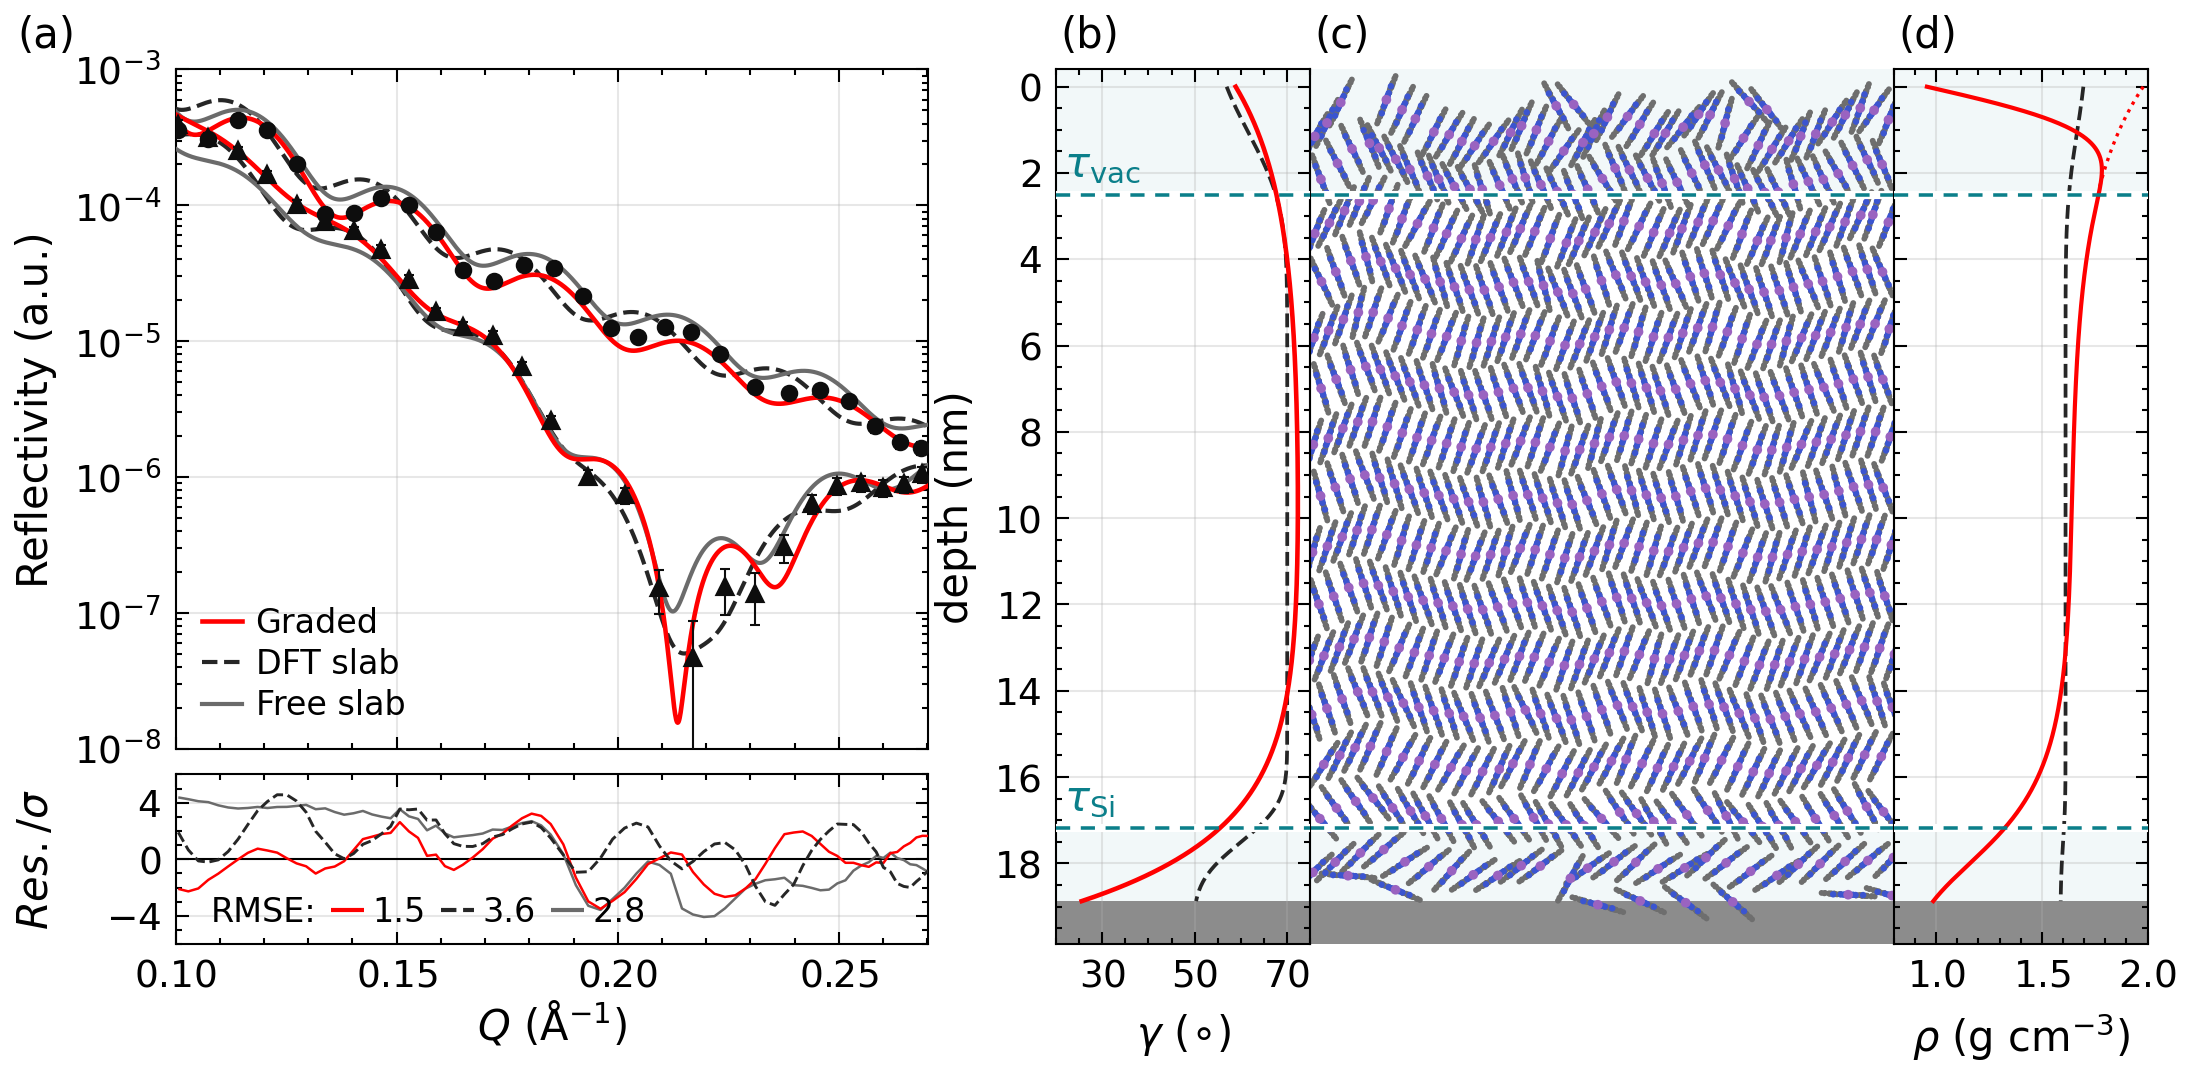

In [25]:
# ---------------------------------------------------------------------------
# Wide plate. Left half, reflectivity and residual. Right half, gamma(z) and
# rho(z) flanking the structure strip with no gutters between them, closed by
# the Si bar. DEPTH_ORIENT swings the whole right half between a vertical
# depth axis (vacuum up) and a horizontal one (the original FIG4 convention).
# ---------------------------------------------------------------------------
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import Affine2D

_MS_DIR = Path.cwd().resolve()
if str(_MS_DIR) not in sys.path:
    sys.path.insert(0, str(_MS_DIR))

import fig4_panel_b_growth as _fig41

importlib.reload(_fig41)

# Substrate treatment for the molecular strip. The reload above resets the
# module default, so the flag has to be set here rather than in an earlier
# cell. See the comparison cell at the end of the notebook.
#   "off"   published behaviour, the acceptance test is on the molecular centre
#   "clip"  reject a molecule whose footprint crosses into the substrate
#   "shift" the same, with the lamellar register seeded where a molecule fits
#   "tilt"  lay the offending molecule flatter until it clears, deleting none
SUBSTRATE_MODE = "off"
SUB_CLEAR = 1
_fig41.SUBSTRATE_MODE = SUBSTRATE_MODE
_fig41.SUB_CLEAR = SUB_CLEAR

# Any mode other than the published one writes to its own name, so an
# experiment cannot silently overwrite the manuscript figure.
SAVENAME = "FIG4" if SUBSTRATE_MODE == "off" else f"FIG4_{SUBSTRATE_MODE}"
HC_EV_A = 12398.419843320026
A2NM = 0.1

# ---- 0. layout switches ------------------------------------------------------
# DEPTH_ORIENT  "vertical"   depth runs down the page, vacuum at the top, the
#                            three depth panels side by side.
#               "horizontal" depth runs left to right, the structure strip on
#                            top of the two profiles, as the PRL FIG4 had it.
# SHOW_WAVE     draws the narrow probe-wave strip alongside the depth panels.
# FILM_ORDER    permutes the three depth panels; the profiles always keep the
#               depth ticks and the tau tags follow the leading profile.
DEPTH_ORIENT = "vertical"
SHOW_WAVE = False
FILM_ORDER = ("gamma", "structure", "rho")
FILM_WIDTH = {"gamma": 1.00, "structure": 2.30, "rho": 1.00}
FILM_HEIGHT = {"structure": 1.30, "gamma": 1.00, "rho": 1.00}
WAVE_WIDTH, WAVE_GAP = 0.22, 0.06  # narrow strip, close against the profiles

HORIZ = DEPTH_ORIENT == "horizontal"

# ---- 1. profiles from the optical model -------------------------------------
_film = extract_graded_fit_context(graded_obj).film
Z_G, RHO_SHARP, RHO_ROUGH = nevot_croce_density(_film)
ALPHA_G = np.degrees(np.asarray(_film.orientation(Z_G), dtype=float))
TOTAL = float(_film.total_thick.value)
TAU_VAC = float(_film.tau_vac.value)
TAU_SI = float(_film.tau_si.value)

Z_DFT = Z_DFT * (TOTAL / float(Z_DFT[-1]))
Z_FREE = Z_FREE * (TOTAL / float(Z_FREE[-1]))

Z_TOP = -4.0  # sliver of vacuum so the surface lamella is not sliced
SUB_NM = 1.0  # solid substrate bar closing the depth panels
SPAN_DISP = TOTAL - Z_TOP
SLAB_T = 14.37 # 11.5 # 13.8
L_MOL = 14.95
LAT_FRAC = 0.955
WAVELENGTH_NM = (HC_EV_A / ENERGY) * A2NM

_fig41.L_MOL = 14.95     # H-inclusive in-plane diameter, tpznpc_0m.xyz
_fig41.LAT_FRAC = 0.955  # lamellar interdigitation, from GIWAXS

ZN_G, ZN_DFT, ZN_FREE = Z_G * A2NM, Z_DFT * A2NM, Z_FREE * A2NM
TOTAL_NM, TAU_VAC_NM, TAU_SI_NM = TOTAL * A2NM, TAU_VAC * A2NM, TAU_SI * A2NM
# Depth limits in drawing order, so the vertical case reads vacuum first.
DEPTH_LIM = (
    (Z_TOP * A2NM, TOTAL_NM + SUB_NM) if HORIZ
    else (TOTAL_NM + SUB_NM, Z_TOP * A2NM)
)

_PACK = _fig41.configure_packing(
    _film,
    z_left=Z_LEFT,
    z_g=Z_G,
    rho_sharp=RHO_SHARP,
    alpha_g=ALPHA_G,
    slab_thick=SLAB_T,
    highlight_fn=lambda ax, *, halo=True: None,  # rules drawn after placement
    xyz_path=_MS_DIR / "tpznpc_0m.xyz",
)
print(
    f"structure: slab {_PACK['slab_thick']:.1f} A, "
    f"bulk cell {_PACK['cell_area']:.1f} A^2/molecule, "
    f"median gamma {_PACK['gamma_median']:.1f} deg, "
    f"lambda {WAVELENGTH_NM:.2f} nm over {TOTAL_NM:.1f} nm of film"
)


# ---- 2. orientation-aware primitives (depth in nm) ---------------------------
# Every painter below draws in (depth, value) and lets these four helpers map
# the pair onto the axes, so one set of code serves both orientations.
def dv(depth, value):
    return (depth, value) if HORIZ else (value, depth)


def depth_rule(ax, z, **kw):
    (ax.axvline if HORIZ else ax.axhline)(z, **kw)


def depth_span(ax, z0, z1, **kw):
    (ax.axvspan if HORIZ else ax.axhspan)(z0, z1, **kw)


def set_depth_lim(ax):
    (ax.set_xlim if HORIZ else ax.set_ylim)(*DEPTH_LIM)


def set_value_lim(ax, lo, hi):
    (ax.set_ylim if HORIZ else ax.set_xlim)(lo, hi)


def set_value_label(ax, text):
    (ax.set_ylabel if HORIZ else ax.set_xlabel)(text)


def value_axis(ax):
    return ax.yaxis if HORIZ else ax.xaxis


def axis_limits(arrays, step, clamp, pad=0.08):
    """Tight limits around the plotted curves, rounded and clamped.

    The FIG4 constants were chosen for a wide horizontal panel and leave most
    of a narrow vertical panel empty, so the window is taken from the curves
    themselves and then clamped so it can never open wider than FIG4 used.
    """
    lo = min(float(np.min(a)) for a in arrays)
    hi = max(float(np.max(a)) for a in arrays)
    m = pad * (hi - lo)
    lo = np.floor((lo - m) / step) * step
    hi = np.ceil((hi + m) / step) * step
    return max(float(lo), clamp[0]), min(float(hi), clamp[1])


def tau_rules(ax):
    for z_tau in (TAU_VAC_NM, TOTAL_NM - TAU_SI_NM):
        depth_rule(ax, z_tau, color="white", lw=TAU_LW + 1.1,
                   solid_capstyle="butt", zorder=4)
        depth_rule(ax, z_tau, color=TAU_COLOR, lw=TAU_LW, ls=TAU_LS,
                   solid_capstyle="butt", zorder=5)


def tau_tags(ax):
    for z_tau, txt in ((TAU_VAC_NM, r"$\tau_\mathrm{vac}$"),
                       (TOTAL_NM - TAU_SI_NM, r"$\tau_\mathrm{Si}$")):
        if HORIZ:
            ax.annotate(txt, xy=(z_tau, 0.04),
                        xycoords=("data", "axes fraction"),
                        xytext=(2, 0), textcoords="offset points",
                        ha="left", va="bottom", color=TAU_COLOR, zorder=10)
        else:
            ax.annotate(txt, xy=(0.03, z_tau),
                        xycoords=("axes fraction", "data"),
                        xytext=(0, 2), textcoords="offset points",
                        ha="left", va="bottom", color=TAU_COLOR, zorder=10)


def zone_bands(ax):
    """Faint tint over the two book-ended zones, carried across every panel."""
    z_vac_edge = DEPTH_LIM[0] if HORIZ else DEPTH_LIM[1]
    depth_span(ax, z_vac_edge, TAU_VAC_NM, color=TAU_COLOR, alpha=0.05,
               lw=0, zorder=0)
    depth_span(ax, TOTAL_NM - TAU_SI_NM, TOTAL_NM, color=TAU_COLOR, alpha=0.05,
               lw=0, zorder=0)


def substrate_bar(ax, label=False, zorder=1):
    """Solid substrate bar closing the deep end of a depth panel.

    ``zorder`` has to clear the molecules on the structure strip, but on the
    profile panels it must sit BELOW the axis. ``axes.axisbelow`` is "line" in
    the project style, which puts the axis (ticks included) at zorder 1.5, so a
    bar drawn above that would swallow the inward ticks instead of letting them
    read against the grey.
    """
    depth_span(ax, TOTAL_NM, TOTAL_NM + SUB_NM, color="0.55", lw=0,
               zorder=zorder)
    if label:
        xy = ((TOTAL_NM + 0.5 * SUB_NM, 0.5) if HORIZ
              else (0.5, TOTAL_NM + 0.5 * SUB_NM))
        cc = ("data", "axes fraction") if HORIZ else ("axes fraction", "data")
        ax.annotate("Si", xy=xy, xycoords=cc, ha="center", va="center",
                    color="white", zorder=9, rotation=90 if HORIZ else 0)


def draw_wave(ax):
    """Incident wave at the probe wavelength, on the shared depth scale.

    Full extent of the depth axis, substrate bar included, with the phase
    origin at the Si interface so the node sits on the substrate and the wave
    is read out of it rather than out of the free surface.
    """
    z = np.linspace(min(DEPTH_LIM), max(DEPTH_LIM), 4000)
    ax.plot(*dv(z, np.sin(2.0 * np.pi * (TOTAL_NM - z) / WAVELENGTH_NM)),
            color=TAU_COLOR, lw=0.8, zorder=3)
    set_value_lim(ax, -1.15, 1.15)
    (ax.set_yticks if HORIZ else ax.set_xticks)([])
    for sp in (("left", "right", "top") if HORIZ else ("top", "right", "bottom")):
        ax.spines[sp].set_visible(False)
    # set_plotting_defaults turns on ticks along every spine (xtick.top,
    # ytick.right) and minor ticks with them. Hiding a spine does not hide its
    # ticks, so they have to go explicitly or they float in the gap before the
    # first profile. Same for the grid, which this strip does not need.
    ax.tick_params(which="both", bottom=not HORIZ, top=False,
                   right=False, left=HORIZ)
    ax.grid(False)


def draw_orientation_v(ax):
    ax.plot(*dv(ZN_FREE, ALPHA_FREE), color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(*dv(ZN_DFT, ALPHA_DFT), color=C_DFT, ls="--", lw=0.9, zorder=3)
    ax.plot(*dv(ZN_G, ALPHA_G), color=C_GRADED, lw=1.1, zorder=5)
    zone_bands(ax)
    tau_rules(ax)
    substrate_bar(ax, zorder=1.2)
    set_value_lim(ax, *axis_limits([ALPHA_G, ALPHA_DFT, ALPHA_FREE], 5.0,
                                   GAMMA_YLIM))
    value_axis(ax).set_major_locator(MaxNLocator(3, prune="both"))
    ax.minorticks_on()
    set_value_label(ax, r"$\gamma$ ($\circ$)")


def draw_density_v(ax):
    surf = Z_G <= TAU_VAC
    ax.plot(*dv(ZN_FREE, RHO_FREE), color=C_FREE, ls="-", lw=0.9, zorder=3)
    ax.plot(*dv(ZN_DFT, RHO_DFT), color=C_DFT, ls="--", lw=0.9, zorder=3)
    ax.plot(*dv(ZN_G[surf], RHO_SHARP[surf]), color=C_GRADED, ls=":", lw=0.8,
            zorder=4)
    ax.plot(*dv(ZN_G, RHO_ROUGH), color=C_GRADED, lw=1.0, zorder=5)
    zone_bands(ax)
    tau_rules(ax)
    substrate_bar(ax, zorder=1.2)
    set_value_lim(ax, *axis_limits([RHO_ROUGH, RHO_DFT, RHO_FREE], 0.1,
                                   RHO_YLIM))
    value_axis(ax).set_major_locator(MaxNLocator(3, prune="both"))
    ax.minorticks_on()
    set_value_label(ax, r"$\rho$ (g cm$^{-3}$)")


# ---- 2b. residuals ----------------------------------------------------------
# Toggle: "linear" -> (R - R_fit) / sigma; "log" -> (ln R - ln R_fit) / (sigma / R).
# RMSE is the RMS of chi over both polarizations (legend).
RESIDUAL_KIND = "linear"  # "linear" | "log"
from matplotlib.lines import Line2D

_RESIDUAL_YLABEL = {
    "linear": r"$Res./\sigma$",
    "log": r"$(\ln R - \ln R_{\mathrm{fit}})/(\sigma/R)$",
}
if RESIDUAL_KIND not in _RESIDUAL_YLABEL:
    raise ValueError(f"RESIDUAL_KIND must be one of {tuple(_RESIDUAL_YLABEL)}, got {RESIDUAL_KIND!r}")


def residual_at(model, pol):
    """x, chi, R_data, R_model, sigma over the plotted q window.

    ``chi`` follows ``RESIDUAL_KIND`` (linear or log-normalized).
    """
    d = getattr(dataset, pol)
    m = d.x >= QMIN
    x = np.asarray(d.x[m], dtype=float)
    r_data = np.asarray(d.y[m], dtype=float)
    sigma = np.asarray(d.y_err[m], dtype=float)
    r_model = np.asarray(rxr(x, model, pol), dtype=float)
    if RESIDUAL_KIND == "linear":
        chi = (r_data - r_model) / sigma
    else:
        chi = log_residual(r_data, r_model, sigma)
    return x, chi, r_data, r_model, sigma


RMSE = {}
print(f"residual kind: {RESIDUAL_KIND}")
print(f"{'model':<11}{'pol':>4}{'n':>5}{'bad':>5}{'med R_d/R_m':>13}"
      f"{'med |chi|':>11}{'rms chi':>10}")
for _mdl in MODELS:
    _chis = []
    for _pol in ("s", "p"):
        _x, _chi, _rd, _rm, _sg = residual_at(_mdl["obj"].model, _pol)
        _chis.append(_chi)
        _bad = int(np.count_nonzero(~np.isfinite(_rm)) + np.count_nonzero(_sg <= 0))
        print(f"{_mdl['name']:<11}{_pol:>4}{len(_x):>5}{_bad:>5}"
              f"{np.median(_rd / _rm):>13.3f}"
              f"{np.median(np.abs(_chi)):>11.2f}"
              f"{np.sqrt(np.mean(_chi ** 2)):>10.2f}")
    RMSE[_mdl["name"]] = float(np.sqrt(np.mean(np.concatenate(_chis) ** 2)))
print("RMSE:", {k: round(v, 1) for k, v in RMSE.items()})


def draw_residual_chi(ax):
    """Residual strip, styling and legend as in ``draw_residual``."""
    ax.axhline(
        0.0,
        color=plt.rcParams["axes.edgecolor"],
        lw=plt.rcParams["axes.linewidth"],
    )
    order = [m for m in MODELS if m["name"] != "DFT slab"] + [
        m for m in MODELS if m["name"] == "DFT slab"
    ]
    for mdl in order:
        x, chi, *_ = residual_at(mdl["obj"].model, "p")
        ax.plot(
            x,
            chi,
            color=mdl["color"],
            ls=mdl["ls"],
            lw=0.7 if mdl["name"] == "DFT slab" else 0.6,
            zorder=6 if mdl["name"] == "DFT slab" else mdl["z"],
            solid_capstyle="butt",
            dash_capstyle="butt",
        )
    ax.set_ylim(*CHI_YLIM)
    ax.set_yticks([-4, 0, 4])
    ax.set_ylabel(_RESIDUAL_YLABEL[RESIDUAL_KIND])
    ax.set_xlim(QMIN, Q.max())
    ax.set_xlabel(r"$Q\ (\mathrm{\AA}^{-1})$")
    rmse_label = Line2D([], [], color="none", label="RMSE:")
    handles = [
        rmse_label,
        *[
            Line2D(
                [],
                [],
                color=mdl["color"],
                ls=mdl["ls"],
                lw=1.0,
                solid_capstyle="butt",
                dash_capstyle="butt",
                label=f"{RMSE[mdl['name']]:.1f}",
            )
            for mdl in MODELS
        ],
    ]

    class _EmptyHandle:
        def legend_artist(self, legend, orig_handle, fontsize, handlebox):
            return None

    ax.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(-0.02, 0.04),
        bbox_transform=ax.transAxes,
        ncols=len(handles),
        # fontsize=6.0,
        handlelength=1,
        handletextpad=0.25,
        columnspacing=0.45,
        borderpad=0.25,
        borderaxespad=0.0,
        labelspacing=0.2,
        framealpha=0.9,
        edgecolor="0.75",
        fancybox=False,
        handler_map={rmse_label: _EmptyHandle()},
    )


# ---- 3. assemble -------------------------------------------------------------
# The depth block takes the larger share of the plate, since the molecular
# strip is the object of the figure and needs lateral room to show the patchy
# near-substrate layer. The middle column is a spacer wide enough to carry the
# depth label (vertical) or the two value labels (horizontal).
#
# PLATE_SPLIT is the width of the depth block relative to the reflectivity
# block. Raising it widens all three depth panels together; FILM_WIDTH then
# decides how much of that extra width lands on the molecular strip.
PLATE_SPLIT = 1.45
FIG_H = 4.35 if HORIZ else 3.6
fig = plt.figure(figsize=(7.2, FIG_H), dpi=300)
outer = fig.add_gridspec(
    1, 3,
    width_ratios=[1.0, 0.17, PLATE_SPLIT],  # middle column is a spacer
    wspace=0.0,
    left=0.075, right=0.988, top=0.935,
    bottom=0.115 if HORIZ else 0.125,
)
left = outer[0].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.06)
axR = fig.add_subplot(left[0])
axres = fig.add_subplot(left[1], sharex=axR)

_keys = list(FILM_ORDER)
if HORIZ:
    # Structure on top, profiles stacked beneath it, sharing the depth axis.
    _keys = ["structure"] + [k for k in FILM_ORDER if k != "structure"]
    _rows = ([WAVE_WIDTH] if SHOW_WAVE else []) + [FILM_HEIGHT[k] for k in _keys]
    grp = outer[2].subgridspec(len(_rows), 1, height_ratios=_rows, hspace=0.26)
else:
    _cols = ([WAVE_WIDTH, WAVE_GAP] if SHOW_WAVE else []) + [
        FILM_WIDTH[k] for k in _keys
    ]
    grp = outer[2].subgridspec(1, len(_cols), width_ratios=_cols, wspace=0.0)

_i0 = (1 if HORIZ else 2) if SHOW_WAVE else 0
axW = fig.add_subplot(grp[0]) if SHOW_WAVE else None
# The structure axes never shares the depth axis: draw_structure blanks its
# ticks and a shared axis would blank the profile depth ticks with them.
_share = axW
_film_axes = {}
for _i, _k in enumerate(_keys):
    _kw = {} if _k == "structure" else {("sharex" if HORIZ else "sharey"): _share}
    _ax = fig.add_subplot(grp[_i0 + _i], **_kw)
    if _k != "structure" and _share is None:
        _share = _ax
    _film_axes[_k] = _ax
axa, axS, axd = (_film_axes[k] for k in ("gamma", "structure", "rho"))
# Adjacent axes share an edge at wspace 0, and the later-created axes wins the
# seam. Lift the profiles so their spines draw over the structure on BOTH
# sides; without this the gamma right spine disappears under the molecules.
axS.set_zorder(1)
for _ax in (axa, axd):
    _ax.set_zorder(2)
    _ax.patch.set_visible(False)

draw_reflectivity(axR)
axR.tick_params(labelbottom=False)
draw_residual_chi(axres)
axres.xaxis.labelpad = 1

if SHOW_WAVE:
    draw_wave(axW)
draw_orientation_v(axa)
draw_density_v(axd)

# Depth ticks belong to the wave strip when it is drawn, otherwise to the
# profile at the outer edge of the stack: leftmost when depth runs down the
# page, bottom-most when it runs across.
_edge = [k for k in _keys if k != "structure"]
_depth_ax = axW if SHOW_WAVE else _film_axes[_edge[-1] if HORIZ else _edge[0]]
for _k, _ax in _film_axes.items():
    if _ax is _depth_ax or _k == "structure":
        continue
    _ax.tick_params(**({"labelbottom": False} if HORIZ else {"labelleft": False}))
(_depth_ax.set_xlabel if HORIZ else _depth_ax.set_ylabel)("depth (nm)")
(_depth_ax.set_xticks if HORIZ else _depth_ax.set_yticks)(
    np.arange(0.0, TOTAL_NM + 0.1, 5.0)
)
tau_tags(_film_axes[_edge[0]])
set_depth_lim(_depth_ax)

# Fix the axa and axd axes x-limits to make sense
# axa.set_xlim(18, 80)
axa.set_xticks([30, 50, 70])

axd.set_xlim(.8, 2)
axd.set_xticks([1, 1.5, 2])

# Fix the depth (y-axis) ticks to be every 2 nm with auto labels
axa.set_yticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])

# ---- 4. structure strip, drawn on a transposed box then moved into place -----
fig.canvas.draw()
_fw, _fh = fig.get_size_inches()
_pos = axS.get_position()
_w_in, _h_in = _pos.width * _fw, _pos.height * _fh
_span_full = _fig41.DEPTH_XLIM[1] - _fig41.DEPTH_XLIM[0]

# fig4_panel_b_growth sizes atoms and bonds from the axes width per angstrom of
# depth, so it is called on a box whose width matches the extent the depth span
# will finally occupy, scaled for the cropped vacuum pad. Point sizes are then
# already right and survive the move back. The lateral overdraw lets the strip
# bleed to the panel edges instead of stopping one molecular radius short.
if HORIZ:  # depth already along x, only the width has to be pre-scaled
    Y_HALF = 0.5 * SPAN_DISP * _h_in / _w_in
    axS.set_position([_pos.x0, _pos.y0,
                      (_w_in * _span_full / SPAN_DISP) / _fw, _h_in / _fh])
else:
    Y_HALF = 0.5 * _w_in * SPAN_DISP / _h_in
    axS.set_position([_pos.x0, _pos.y0,
                      (_h_in * _span_full / SPAN_DISP) / _fw, _w_in / _fh])
axS.set_xlim(*_fig41.DEPTH_XLIM)
axS.set_ylim(-Y_HALF, Y_HALF)
_fig41.draw_structure(axS, Y_HALF + 0.30 * _fig41.L_MOL)
axS.set_position(_pos)

# ---- 4b. diffraction from the strip that was just drawn ----------------------
# Cell 11 compares d-spacings taken from the lattice algebra, which never sees
# the drawing. These come from the drawn atom coordinates instead, so changing
# SUBSTRATE_MODE above cannot quietly move the packing without showing up here.
# Read while the coordinates are still in angstrom, before the transform below.
Q_CHECK = np.linspace(0.25, 2.50, 900)


def _drawn_atoms(ax):
    """Drawn atom positions, column 0 depth and column 1 lateral, in angstrom."""
    return np.vstack([_c.get_offsets() for _c in ax.collections
                      if not isinstance(_c, LineCollection)])


def structure_factor(coords, axis, q, taper=False, chunk=64):
    """|sum_j w_j exp(i q x_j)|^2 along one axis of the drawn strip.

    Unit atomic weights, which is enough to locate a period. The lateral
    transform is tapered by a raised cosine, since the hard edge of the strip
    otherwise rings at 2 pi over its width and buries the column peak. The
    depth transform is left untapered so the substrate region keeps its weight.
    """
    x = np.asarray(coords[:, axis], dtype=float)
    w = np.ones_like(x)
    if taper:
        u = (x - x.min()) / max(float(np.ptp(x)), 1e-9)
        w = 0.5 - 0.5 * np.cos(2.0 * np.pi * u)
    out = np.empty_like(q)
    for _i in range(0, q.size, chunk):
        _ph = np.outer(q[_i:_i + chunk], x)
        out[_i:_i + chunk] = ((np.cos(_ph) * w).sum(1) ** 2
                              + (np.sin(_ph) * w).sum(1) ** 2)
    return out / max(w.sum(), 1.0) ** 2


def peak_near(q, s, q0, half=0.25):
    """Location of the strongest feature within +/- half of q0."""
    _m = (q > q0 - half) & (q < q0 + half)
    return float(q[_m][np.argmax(s[_m])]) if np.any(_m) else float("nan")


_XY_DRAWN = _drawn_atoms(axS)
S_LAM = structure_factor(_XY_DRAWN, 0, Q_CHECK)
S_COL = structure_factor(_XY_DRAWN, 1, Q_CHECK, taper=True)
Q_LAM_DRAWN = peak_near(Q_CHECK, S_LAM, 0.50)
Q_COL_DRAWN = peak_near(Q_CHECK, S_COL, 1.89)
N_DRAWN = len(_XY_DRAWN) / max(int(np.count_nonzero(_fig41.KEEP)), 1)
N_TAU_SI = np.count_nonzero(_XY_DRAWN[:, 0] > TOTAL - TAU_SI) / max(
    int(np.count_nonzero(_fig41.KEEP)), 1)
print(
    f"drawn strip: SUBSTRATE_MODE={SUBSTRATE_MODE!r}  {N_DRAWN:.0f} molecules, "
    f"{N_TAU_SI:.0f} inside tau_Si\n"
    f"  lamellar  q = {Q_LAM_DRAWN:.4f} 1/A   d = {2 * np.pi / Q_LAM_DRAWN:6.2f} A\n"
    f"  column    q = {Q_COL_DRAWN:.4f} 1/A   d = {2 * np.pi / Q_COL_DRAWN:6.2f} A"
)


for _txt in list(axS.texts):  # module labels are axes-fraction, wrong after rot
    _txt.remove()

# angstrom -> nm, and (depth, lateral) -> (-lateral, depth) when depth is down
_trans = (Affine2D().scale(A2NM) if HORIZ
          else Affine2D().rotate_deg(90).scale(A2NM))
for _coll in axS.collections:
    if isinstance(_coll, LineCollection):
        _coll.set_transform(_trans + axS.transData)
    else:  # scatter: offsets transform, marker paths are points and must not
        _coll.set_offset_transform(_trans + axS.transData)

if HORIZ:
    axS.set_xlim(*DEPTH_LIM)
    axS.set_ylim(-Y_HALF * A2NM, Y_HALF * A2NM)
else:
    axS.set_xlim(-Y_HALF * A2NM, Y_HALF * A2NM)
    axS.set_ylim(*DEPTH_LIM)
zone_bands(axS)
tau_rules(axS)
substrate_bar(axS, label=False)
axS.set_xticks([])
axS.set_yticks([])
axS.tick_params(which="both", bottom=False, left=False,
                labelbottom=False, labelleft=False)
for _sp in (("top", "bottom") if HORIZ else ("left", "right")):
    axS.spines[_sp].set_visible(True)
    axS.spines[_sp].set_color("0.6")

# Common model key for depth panels, centered under gamma..rho in figure space.
_blk = [axa.get_position(), axd.get_position()]
_x0, _x1 = min(p.x0 for p in _blk), max(p.x1 for p in _blk)
# _depth_legend = fig.legend(
#     handles=[
#         Line2D([], [], color=C_GRADED, ls="-", lw=1.1, label="Grad."),
#         Line2D([], [], color=C_DFT, ls="--", lw=0.9, label="Slab"),
#     ],
#     loc="upper center",
#     bbox_to_anchor=(0.5 * (_x0 + _x1), min(p.y0 for p in _blk) - 0.01),
#     bbox_transform=fig.transFigure,
#     frameon=False,
#     ncol=2,
#     handlelength=1.4,
#     handletextpad=0.3,
#     columnspacing=.5,
# )
# _depth_legend.set_zorder(20)

# ---- 5. panel letters -------------------------------------------------------
# House convention from FIG3 and fig_4_hero_fit: lowercase in parentheses,
# regular weight, top left of the panel. The reflectivity keeps the gutter
# placement, since it has a y label to sit beside. The depth panels are butted
# together with no gutter, so a gutter label would land inside the neighbour;
# those sit just above the top spine instead, which is the same exception the
# hero figure makes for its narrow panels. Letters follow the drawn order, left
# to right or top to bottom, so they stay correct if FILM_ORDER is permuted.
PANEL_LETTERS = "abcdefgh"
_stack = ([axW] if SHOW_WAVE else []) + list(_film_axes.values())
_stack.sort(key=(lambda a: -a.get_position().y1) if HORIZ
            else (lambda a: a.get_position().x0))
_labelled = [(axR, -38.0), *((_a, 1.0) for _a in _stack)]
for _tag, (_ax, _dx) in zip(PANEL_LETTERS, _labelled):
    _ax.annotate(
        f"({_tag})",
        xy=(0.0, 1.0),
        xycoords="axes fraction",
        xytext=(_dx, 3.0),
        textcoords="offset points",
        va="bottom",
        ha="left",
        annotation_clip=False,
    )

fig.align_ylabels([axR, axres])
fig.savefig(f"{SAVENAME}.pdf", dpi=600, transparent=True)
fig.savefig(f"{SAVENAME}.png", dpi=600, transparent=True)
plt.show()


In [28]:
print(refloxide_objective.parameters)

________________________________________________________________________________
Parameters: 'reflect_model'
________________________________________________________________________________
Parameters: 'experiment_corrections'
________________________________________________________________________________
Parameters:    'shared'    
<Parameter:'energy_offset', value=0.00349378  (fixed) , bounds=[-1.0, 1.0]>
<Parameter:     'dq'      , value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
________________________________________________________________________________
Parameters: 'instrument@250p0eV'
<Parameter:'scale_s@250p0eV', value=1.04835 +/- 0.0133, bounds=[1.0483522692686418, 1.208352269268642]>
<Parameter:'scale_p@250p0eV', value=1.17289 +/- 0.0148, bounds=[1.1728872111914304, 1.3328872111914305]>
<Parameter: 'bkg@250p0eV' , value=7.14339e-08  (fixed) , bounds=[-inf, inf]>
<Parameter:'theta_offset_s@250p0eV', value=0.356196 +/

FROM THE SIMULATION
  fitted plateau density            1.639 g/cm3
  molar mass (from the xyz)        577.92 g/mol
  volume per molecule               585.7 A^3
  SLAB_THICK                        14.37 A   (area)
  L_MOL x LAT_FRAC                  14.28 A   (aspect ratio)
  PI_STACK                           3.40 A
  median gamma                       70.4 deg
  bulk cell area = V/SLAB_THICK     40.76 A^2

  depth superposition, estimator = 'peak'
    lamellar (out-of-plane)   d =  12.35 A   q = 0.509 +/- 0.027
    column   (in-plane)       d =   3.26 A   q = 1.928 +/- 0.026

  the two estimators side by side (d in A, centre only)
    lamellar   mean 12.076   peak 12.348
    column     mean  3.582   peak  3.259

MEASURED (pseudo-Voigt on a local background)
  out-of-plane order 1   q = 0.4997 +/- 0.0003   d = 12.574 A   FWHM = 0.0579   q_n/q_1 = 1.000
  out-of-plane order 2   q = 0.9982 +/- 0.0059   d =  6.294 A   FWHM = 0.1207   q_n/q_1 = 1.998
  out-of-plane order 3   q = 1.4968 +

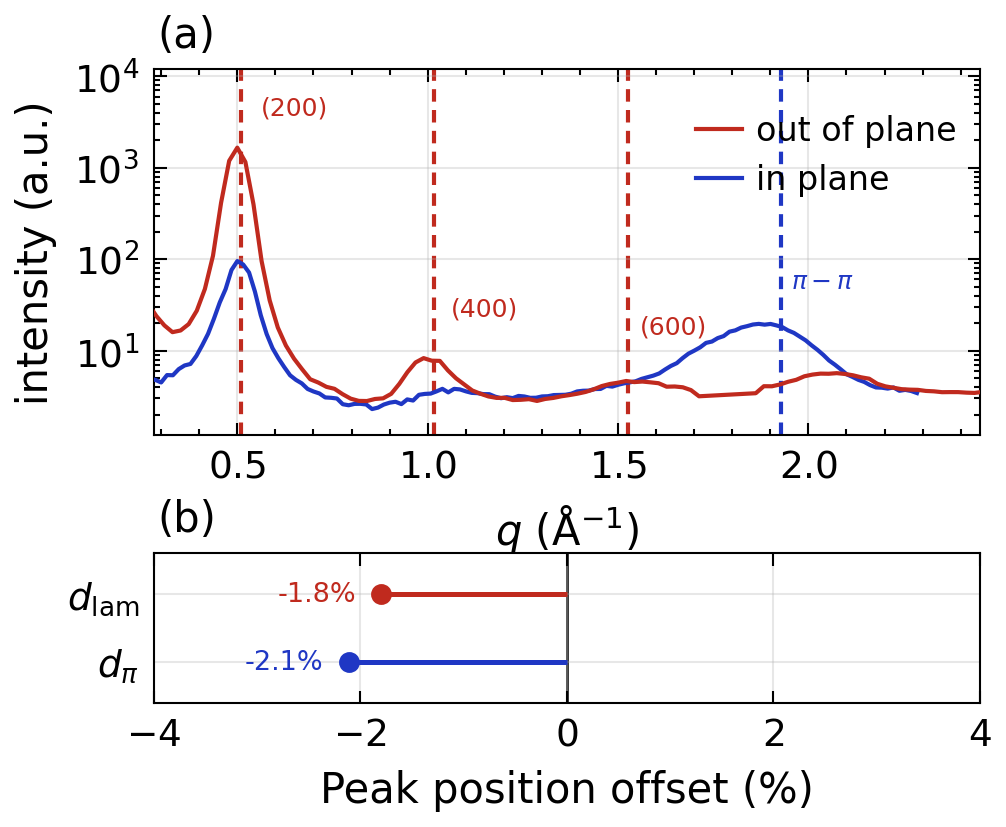

In [8]:
# ---------------------------------------------------------------------------
# GIWAXS consistency check for the panel (c) packing, and the supplemental
# figure that carries it.
#
# Self-contained. Run any time after the packing cell. Depends only on _fig41
# (the fig4_panel_b_growth module), the Xeuss export beside this notebook, and
# numpy / pandas / scipy / matplotlib.
#
# The strip's projected lattice is orthogonal: a lamellar period along depth
# and a column period in-plane. Their PRODUCT is the cell area, fixed by rho(z)
# and SLAB_THICK; their RATIO is fixed by L_MOL * LAT_FRAC / PI_STACK and
# sin^2(gamma). So the two measured in-plane / out-of-plane peaks pin the two
# knobs independently, and panel (b) of the figure shows which of the two the
# diffraction actually tests.
# ---------------------------------------------------------------------------
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator, NullFormatter
from matplotlib.transforms import blended_transform_factory
from scipy.optimize import curve_fit

_P = _fig41

# ---- inputs ----------------------------------------------------------------
SAVENAME_SI = "SI_GIWAXS"
CSV = Path.cwd().resolve() / "XuessGiwaxs.csv"
CUT_OOP, CUT_IP = "90_10", "170_10"  # azimuthal sectors, degrees from horizon
MASK = (1.72, 1.85)  # detector gap in the out-of-plane cut

# Peak windows as (starting q, half width). The out-of-plane fundamental
# carries the lamellar spacing; orders 2 and 3 only test that the stack is
# periodic, and order 3 sits on the diffuse floor so its centre is soft.
PEAKS_OOP = ((0.500, 0.075), (0.989, 0.100), (1.521, 0.100))
PEAK_IP = (1.870, 0.180)

# (002) is the third direction, along the viewing axis. Neither sector resolves
# it, so it stays a hand-set input and only enters the beta bookkeeping below.
Q_002 = 0.52

# Packing knobs. None keeps whatever the packing cell set. A number overrides
# the module in place, which is enough for the numbers below, but the DRAWING
# only follows once you put the same value in the packing cell and re-run it.
SLAB_THICK_OVR = None    # try 14.37
L_MOL_OVR = None         # try 14.95, the H-inclusive in-plane diameter
LAT_FRAC_OVR = None      # try 0.955 alongside L_MOL = 14.95

Z_CELL = 4               # molecules per unit cell, alpha-ZnPc convention
BETA_LIT = 121.6         # alpha-ZnPc, monoclinic C2/c
ABC_LIT = (25.92, 3.79, 23.92)

SHOW_LABELS = True       # Miller labels are an assignment, not a model output

# Estimator for the model peak. "peak" locates the maximum of the depth
# superposition, which is the quantity a diffractometer reports. "mean" is the
# weighted mean spacing, the module's original statistic. They are different
# functionals of the same distribution and separate by several percent whenever
# 1/sin^2(gamma) skews it, which the disordered book-ends guarantee.
ESTIMATOR = "peak"
SIGMA_INST = 0.02        # instrumental Gaussian sigma in q, 1/A
C_OOP, C_IP = "#c02a1e", "#1f37c4"

_applied = []
for _name, _val in (("SLAB_THICK", SLAB_THICK_OVR), ("L_MOL", L_MOL_OVR),
                    ("LAT_FRAC", LAT_FRAC_OVR)):
    if _val is not None:
        setattr(_P, _name, float(_val))
        _applied.append(f"{_name}={_val}")


# ---- 1. the lattice the simulation predicts --------------------------------
# This is the only place L_MOL, LAT_FRAC and PI_STACK do any work. They set the
# cell's aspect ratio; rho(z) and SLAB_THICK set its area.
def _lattice(z):
    """Lamellar period (depth) and column period (lateral) at depth z, in A."""
    s_g = float(np.clip(abs(np.sin(np.radians(_P._gamma(z)))),
                        _P.SIN_GAMMA_MIN, 1.0))
    area = _P.cell_area(z)
    ratio = _P.L_MOL * _P.LAT_FRAC * s_g**2 / _P.PI_STACK
    aniso = 1.0 + _P.STRAIN_ANISO_SI * float(
        np.exp(-(_P.TOTAL - z) / _P.TAU_SI))
    return np.sqrt(area * ratio) * aniso, np.sqrt(area / ratio) / aniso


_z = _P.Z_G[(_P.Z_G >= 0.0) & (_P.Z_G <= _P.TOTAL)]
_dl, _cs = np.array([_lattice(z) for z in _z]).T

# GIWAXS samples the film by scattering power, not by volume. Weight each depth
# by the local density times a Debye-Waller factor built from the same
# positional disorder the strip draws, so the buried interface contributes
# material but little coherent Bragg intensity.
_u = _P.POS_DISORDER_VAC + (_P.POS_DISORDER_SI - _P.POS_DISORDER_VAC) * (
    _z / _P.TOTAL)
_rho = np.clip(np.interp(_z, _P.Z_G, _P.RHO_MAT), 0.0, None)


def _weights(d):
    q = 2.0 * np.pi / d
    w = _rho * np.exp(-(q**2) * _u**2)
    return q, w / w.sum(axis=-1, keepdims=True)


def _stat_mean(d):
    """Weighted mean q, its depth dispersion, and the weighted mean spacing."""
    q, w = _weights(d)
    qm = float((w * q).sum(-1))
    return qm, float(np.sqrt((w * (q - qm) ** 2).sum(-1))), float((w * d).sum(-1))


def _peak_q(d, iters=60):
    """Maximum of the depth superposition, found by mean shift on the sample.

    Every depth contributes a Gaussian of width SIGMA_INST centred on its own
    q, weighted as above. The mode of that sum is what the measurement returns.
    Mean shift converges to it without ever building the profile, so this stays
    cheap enough to evaluate over a grid of packing constants.
    """
    q, w = _weights(d)
    x = (w * q).sum(-1)
    for _ in range(iters):
        k = w * np.exp(-0.5 * ((q - np.asarray(x)[..., None]) / SIGMA_INST) ** 2)
        s = k.sum(-1)
        x = np.where(s > 0.0, (k * q).sum(-1) / np.where(s > 0.0, s, 1.0), x)
    return x


def _stat_peak(d):
    """Peak q, HALF the predicted FWHM, and the spacing at the peak."""
    q, w = _weights(d)
    x = float(_peak_q(d))
    span = 0.9 * max(x, 0.3)
    qq = np.linspace(x - span, x + span, 2000)
    prof = (w[:, None]
            * np.exp(-0.5 * ((qq[None, :] - q[:, None]) / SIGMA_INST) ** 2)).sum(0)
    m = prof >= 0.5 * prof.max()
    return x, 0.5 * float(qq[m].max() - qq[m].min()), 2.0 * np.pi / x


def _stat(d):
    """Centre, band half width, and spacing under the selected estimator.

    The second element is the depth dispersion for "mean" and half the
    predicted FWHM for "peak", so the figure draws a band either way, but
    under "peak" that band is a prediction of the measured peak width.
    """
    return _stat_peak(d) if ESTIMATOR == "peak" else _stat_mean(d)


q_oop, s_oop, d_oop = _stat(_dl)
q_ip, s_ip, d_ip = _stat(_cs)

_vol_mol = _P.MOLAR_MASS / (_P.RHO_BULK_REF * _P.N_AVOGADRO * 1e-24)
_gam_med = float(np.median(np.interp(_z, _P.Z_G, _P.ALPHA_G)))
_sin2 = np.sin(np.radians(_gam_med)) ** 2


# ---- 2. the measured linecuts ----------------------------------------------
def linecut(df, tag):
    """Finite, positive part of one azimuthal sector."""
    q = df[f"q_ZnPc_0_00000_{tag}"].to_numpy(float)
    r = df[f"r_ZnPc_0_00000_{tag}"].to_numpy(float)
    m = np.isfinite(q) & np.isfinite(r) & (r > 0)
    return q[m], r[m]


def _pseudo_voigt(x, q0, sig, eta, amp, b0, b1):
    s = max(abs(sig), 1e-4)
    gauss = np.exp(-0.5 * ((x - q0) / s) ** 2)
    lorentz = 1.0 / (1.0 + ((x - q0) / s) ** 2)
    return amp * ((1 - eta) * gauss + eta * lorentz) + b0 + b1 * (x - q0)


def fit_peak(q, r, q_guess, half):
    """Pseudo-Voigt on a local linear background. Centre, its error, FWHM.

    The background is local rather than global because the cut spans four
    decades and no single power law describes both the low-q upturn and the
    diffuse floor.
    """
    m = (q > q_guess - half) & (q < q_guess + half)
    x, y = q[m], r[m]
    bg = float(np.percentile(y, 15))
    p0 = [q_guess, 0.025, 0.3, max(y.max() - bg, 1.0), bg, 0.0]
    lo = [q_guess - 0.5 * half, 0.005, 0.0, 0.0, -5 * abs(bg) - 10, -1e6]
    hi = [q_guess + 0.5 * half, half, 1.0, np.inf, abs(y.max()) + 10, 1e6]
    p, cov = curve_fit(_pseudo_voigt, x, y, p0=p0, bounds=(lo, hi),
                       sigma=np.sqrt(np.abs(y)), maxfev=40000)
    return p[0], float(np.sqrt(np.diag(cov))[0]), 2.3548 * abs(p[1])


_df = pd.read_csv(CSV)
Q_OOP_DATA, R_OOP_DATA = linecut(_df, CUT_OOP)
Q_IP_DATA, R_IP_DATA = linecut(_df, CUT_IP)

_orders = [fit_peak(Q_OOP_DATA, R_OOP_DATA, _g, _h) for _g, _h in PEAKS_OOP]
Q_OOP, E_OOP, W_OOP = _orders[0]
Q_IP, E_IP, W_IP = fit_peak(Q_IP_DATA, R_IP_DATA, *PEAK_IP)
_d200, _d002, _d010 = 2 * np.pi / Q_OOP, 2 * np.pi / Q_002, 2 * np.pi / Q_IP

print("=" * 66)
if _applied:
    print("OVERRIDES APPLIED TO THE MODULE: " + ", ".join(_applied))
    print("  (re-run the packing cell with the same values to move the drawing)")
print("FROM THE SIMULATION")
print(f"  fitted plateau density         {_P.RHO_BULK_REF:8.3f} g/cm3")
print(f"  molar mass (from the xyz)      {_P.MOLAR_MASS:8.2f} g/mol")
print(f"  volume per molecule            {_vol_mol:8.1f} A^3")
print(f"  SLAB_THICK                     {_P.SLAB_THICK:8.2f} A   (area)")
print(f"  L_MOL x LAT_FRAC               "
      f"{_P.L_MOL * _P.LAT_FRAC:8.2f} A   (aspect ratio)")
print(f"  PI_STACK                       {_P.PI_STACK:8.2f} A")
print(f"  median gamma                   {_gam_med:8.1f} deg")
print(f"  bulk cell area = V/SLAB_THICK  {_vol_mol / _P.SLAB_THICK:8.2f} A^2")
print(f"\n  depth superposition, estimator = {ESTIMATOR!r}")
print(f"    lamellar (out-of-plane)   d = {d_oop:6.2f} A   "
      f"q = {q_oop:.3f} +/- {s_oop:.3f}")
print(f"    column   (in-plane)       d = {d_ip:6.2f} A   "
      f"q = {q_ip:.3f} +/- {s_ip:.3f}")
print("\n  the two estimators side by side (d in A, centre only)")
for _lab, _d in (("lamellar", _dl), ("column  ", _cs)):
    print(f"    {_lab}   mean {_stat_mean(_d)[2]:6.3f}   "
          f"peak {_stat_peak(_d)[2]:6.3f}")

print("\nMEASURED (pseudo-Voigt on a local background)")
for _n, (_q, _e, _w) in enumerate(_orders, start=1):
    print(f"  out-of-plane order {_n}   q = {_q:.4f} +/- {_e:.4f}   "
          f"d = {2 * np.pi / _q:6.3f} A   FWHM = {_w:.4f}   "
          f"q_n/q_1 = {_q / Q_OOP:.3f}")
print(f"  in-plane pi stack     q = {Q_IP:.4f} +/- {E_IP:.4f}   "
      f"d = {_d010:6.3f} A   FWHM = {W_IP:.4f}")

print("\nMEASURED vs MODEL")
for _lab, _qm, _dm, _qs, _ds in (
        ("(200) out-of-plane", Q_OOP, _d200, q_oop, d_oop),
        ("(pi-pi) in-plane  ", Q_IP, _d010, q_ip, d_ip)):
    print(f"  {_lab}  q {_qm:6.3f} / {_qs:6.3f}   "
          f"d {_dm:6.2f} / {_ds:6.2f}   {100 * (_ds / _dm - 1):+5.1f}%")
print(f"  cell area           "
      f"d_lam x d_pi {_d200 * _d010:6.2f} / {d_oop * d_ip:6.2f}   "
      f"{100 * (d_oop * d_ip / (_d200 * _d010) - 1):+5.1f}%")

print("\nIMPLIED KNOBS (from the out-of-plane / pi-pi pair)")
print(f"  SLAB_THICK       = {_vol_mol / (_d200 * _d010):7.2f} A   "
      f"(now {_P.SLAB_THICK:.2f})")
print(f"  L_MOL x LAT_FRAC = {(_d200 / _d010) * _P.PI_STACK / _sin2:7.2f} A   "
      f"(now {_P.L_MOL * _P.LAT_FRAC:.2f})")
print("    L_MOL and LAT_FRAC are exactly degenerate, only the product matters:")
for _lm in (13.18, 13.60, 14.95):
    print(f"      L_MOL = {_lm:5.2f}  ->  LAT_FRAC = "
          f"{(_d200 / _d010) * _P.PI_STACK / _sin2 / _lm:.3f}")

# ---- 3. beta and the implied unit cell -------------------------------------
# beta is the monoclinic angle between a and c. It is NOT a simulation output:
# the packing model is a 2D projection with an orthogonal projected lattice and
# a slab thickness measured perpendicular to the page, so it holds no inclined
# axis. beta only appears when that perpendicular thickness is set against a
# spacing measured along an inclined crystallographic axis.
#
# For monoclinic b-unique with Z molecules per cell,
#   d_200 = (a/2) sin(beta),  d_002 = (c/2) sin(beta),  d_010 = b,
#   V_cell = a b c sin(beta) = Z * V_molecule
# eliminating a, b and c gives
#   sin(beta) = 4 d_200 d_002 d_010 / (Z V_molecule)
# so beta comes from three MEASURED spacings; the simulation contributes only
# the volume per molecule.
_sinb = 4 * _d200 * _d002 * _d010 / (Z_CELL * _vol_mol)
_beta = 180.0 - np.degrees(np.arcsin(np.clip(_sinb, 0.0, 1.0)))
_a_f, _b_f, _c_f = 2 * _d200 / _sinb, _d010, 2 * _d002 / _sinb
_rho_lit = _P.MOLAR_MASS / (
    (ABC_LIT[0] * ABC_LIT[1] * ABC_LIT[2] * np.sin(np.radians(BETA_LIT))
     / Z_CELL) * _P.N_AVOGADRO * 1e-24)

print("\nUNIT CELL (all three measured peaks + the fitted density)")
print(f"  {'':16s}{'this film':>10s}{'alpha-ZnPc':>12s}{'diff':>8s}")
for _n, _v, _l in (("a (A)", _a_f, ABC_LIT[0]), ("b (A)", _b_f, ABC_LIT[1]),
                   ("c (A)", _c_f, ABC_LIT[2]), ("beta (deg)", _beta, BETA_LIT),
                   ("density", _P.RHO_BULK_REF, _rho_lit)):
    print(f"  {_n:16s}{_v:10.2f}{_l:12.2f}{100 * (_v / _l - 1):+7.0f}%")
print("\n  CAUTION. beta lands close to the literature value, but a, b and c")
print("  are off by more than 10%, so the beta agreement alone is not evidence")
print("  the assignment is right. Treat it as a consistency figure only.")
print("=" * 66)

# ---- 4. supplemental figure, single column ----------------------------------
fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(3.4, 2.5), dpi=300,
    gridspec_kw={"height_ratios": [2.45, 1.0], "hspace": 0.46,
                 "left": 0.165, "right": 0.975, "top": 0.945, "bottom": 0.100},
)

# Model positions as bands, half width the depth dispersion. A hairline would
# claim a precision the graded film does not have: every depth carries its own
# spacing, and the band is that spread.
for _n in (1, 2, 3):
    # axA.axvspan(_n * (q_oop - s_oop), _n * (q_oop + s_oop), color=C_OOP,
    #             alpha=0.13, lw=0, zorder=0)
    axA.axvline(_n * q_oop, color=C_OOP, ls=(0, (3, 2)), lw=1, alpha=1,
                zorder=1)
# axA.axvspan(q_ip - s_ip, q_ip + s_ip, color=C_IP, alpha=0.13, lw=0, zorder=0)
axA.axvline(q_ip, color=C_IP, ls=(0, (3, 2)), lw=1, alpha=1, zorder=1)

_gap = (Q_OOP_DATA > MASK[0]) & (Q_OOP_DATA < MASK[1])
axA.plot(Q_OOP_DATA, np.where(_gap, np.nan, R_OOP_DATA), color=C_OOP, lw=1.0,
         zorder=4, label="out of plane")
axA.plot(Q_IP_DATA, R_IP_DATA, color=C_IP, lw=1.0, zorder=3, label="in plane")

# The detector gap is marked as a short bar at the top edge rather than a
# full-height band, which would collide with the model bands.
_bt = blended_transform_factory(axA.transData, axA.transAxes)
# axA.add_patch(Rectangle((MASK[0], 0.965), MASK[1] - MASK[0], 0.035,
#                         transform=_bt, facecolor="0.55", lw=0, zorder=6,
#                         clip_on=False))
# axA.annotate("gap", xy=(0.5 * sum(MASK), 0.955), xycoords=_bt, ha="center",
#              va="top", fontsize=5.5, color="0.45")

if SHOW_LABELS:
    for (_q, _, _), _lab, _sc in zip(_orders, ("(200)", "(400)", "(600)"),
                                     (2.0, 2.6, 3.0)):
        axA.annotate(_lab, xy=(_q+0.15, np.interp(_q, Q_OOP_DATA, R_OOP_DATA) * _sc),
                     ha="center", va="bottom", fontsize=6, color=C_OOP)
    axA.annotate(r"$\pi-\pi$",
                 xy=(Q_IP+0.15, np.interp(Q_IP, Q_IP_DATA, R_IP_DATA) * 2.2),
                 ha="center", va="bottom", fontsize=6, color=C_IP)

axA.set_yscale("log")
axA.set_xlim(0.28, 2.45)
axA.set_ylim(1.2, 1.2e4)
axA.xaxis.set_major_locator(MultipleLocator(0.5))
axA.xaxis.set_minor_locator(MultipleLocator(0.1))
axA.yaxis.set_minor_formatter(NullFormatter())
axA.set_xlabel(r"$q\ (\mathrm{\AA}^{-1})$")
axA.set_ylabel("intensity (a.u.)")
axA.legend(loc="upper right", bbox_to_anchor=(1.0, 0.94), frameon=False,
           handlelength=1.4, handletextpad=0.4, borderaxespad=0.3)

# Panel b. The two spacings as model minus measurement.
_rows = (
    (r"$d_\mathrm{lam}$", d_oop, _d200, C_OOP),
    (r"$d_\pi$", d_ip, _d010, C_IP),
)
_y = np.arange(len(_rows))[::-1]
# Symmetric window sized to the largest deviation, so nothing is ever clipped.
_devs = [100.0 * (_m / _x - 1.0) for _, _m, _x, _ in _rows]
_span = max(14.0, 1.45 * max(abs(_d) for _d in _devs))
axB.axvline(0.0, color="0.2", lw=0.7, zorder=1)
for _g in np.arange(-50.0, 50.1, 5.0):
    if 0.0 < abs(_g) < _span:
        axB.axvline(_g, color="0.85", lw=0.5, ls=(0, (1, 2)), zorder=0)
for _yy, (_lab, _mod, _mea, _col) in zip(_y, _rows):
    _dev = 100.0 * (_mod / _mea - 1.0)
    axB.plot([0, _dev], [_yy, _yy], color=_col, lw=1.2, zorder=2,
             solid_capstyle="butt")
    axB.plot([_dev], [_yy], "o", color=_col, ms=4.0, zorder=3)
    axB.annotate(f"{_dev:+.1f}%", xy=(_dev, _yy),
                 xytext=(6 if _dev >= 0 else -6, 0), textcoords="offset points",
                 ha="left" if _dev >= 0 else "right", va="center",
                 fontsize=6.5, color=_col)
axB.set_yticks(_y)
axB.set_yticklabels([r[0] for r in _rows])
axB.set_ylim(-0.6, len(_rows) - 0.4)
axB.set_xlim(-4, 4)
axB.set_xlabel("Peak position offset (%)")
axB.tick_params(axis="y", which="both", left=False, right=False)
axB.minorticks_off()

for _ax, _tag in ((axA, "a"), (axB, "b")):
    _ax.annotate(f"({_tag})", xy=(0.0, 1.0), xycoords="axes fraction",
                 xytext=(1.0, 3.0), textcoords="offset points",
                 va="bottom", ha="left", annotation_clip=False)

fig.savefig(f"{SAVENAME_SI}.pdf", dpi=600, transparent=True)
fig.savefig(f"{SAVENAME_SI}.png", dpi=600, transparent=True)
plt.show()


PEAK WIDTHS. size broadening against paracrystalline disorder
  lamellar FWHM by order   n=1 0.0579  n=2 0.1207  n=3 0.2355
  ratios to the first       1.00   2.09   4.07   (n^2 would be 1, 4, 9)
  fit beta = 2pi/L + 2pi^3 g^2 n^2 / d
    coherence L        184 A   against a film thickness of 189 A
    paracrystal g      6.7 %

  column peak, one order only, so the two terms cannot be separated
    if all disorder      g = 14.1 %, L unbounded
    if g matches the lamellar 6.7 %, L = 22 A = 6.6 molecules
    the second column order would sit at q = 3.77 1/A, beyond this cut
GROUND TRUTH, nothing here is adjustable
  molar mass (xyz stoichiometry)        577.92 g/mol
  plateau density (fit)                  1.639 g/cm3
  volume per molecule                    585.7 A^3
  median gamma (fit)                      70.4 deg
  rho(z), gamma(z)                     the fitted profiles

BOUNDED BY THE XYZ GEOMETRY
  heavy-atom span                        13.18 A
  hydrogen-inclusive span         

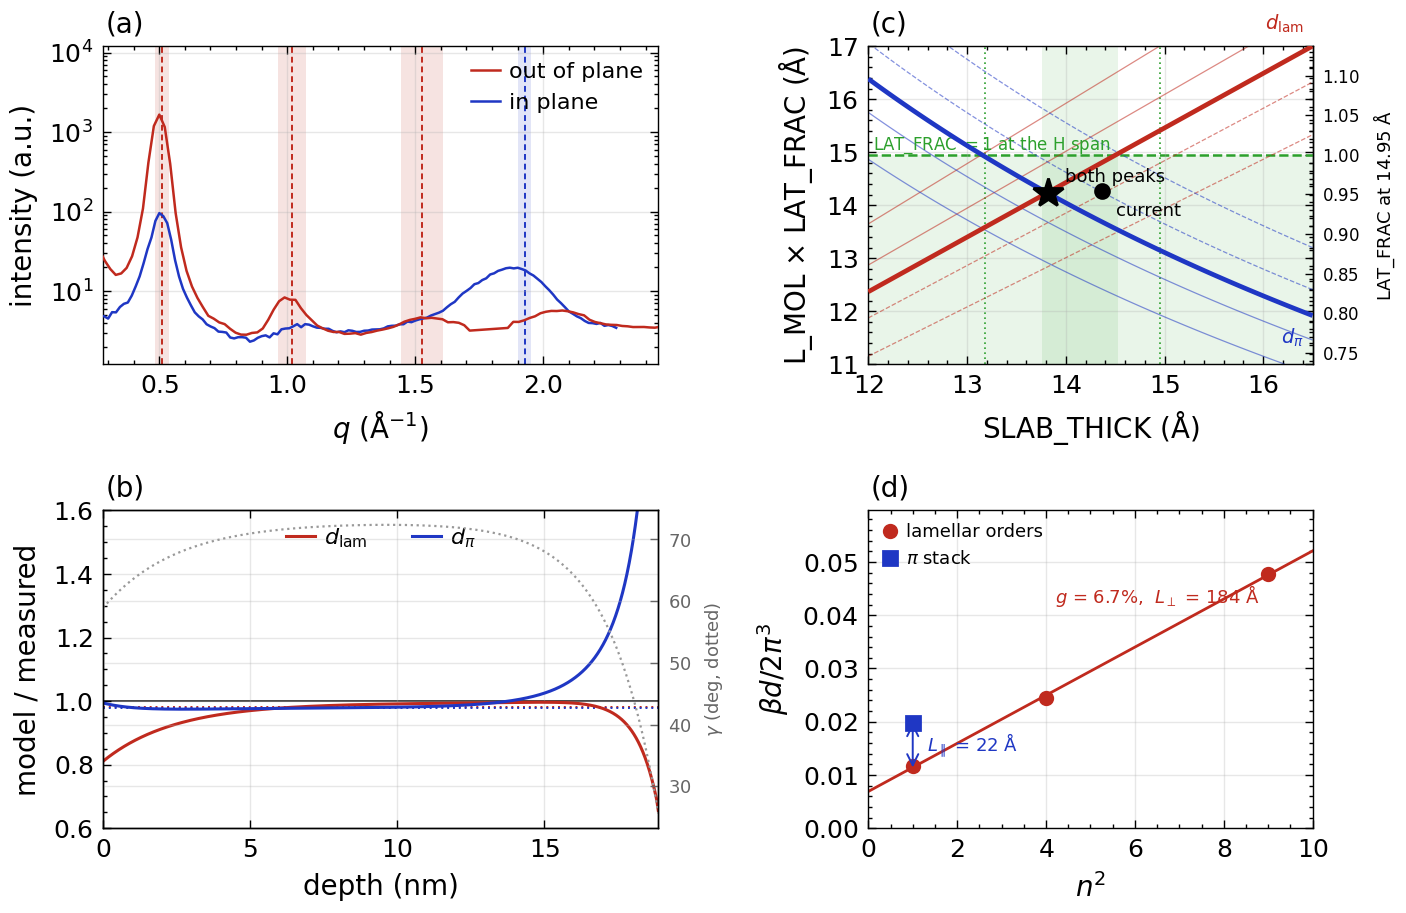

In [16]:
# ---------------------------------------------------------------------------
# Packing tuning dashboard. Working cell, not a manuscript figure.
#
# Run after the GIWAXS cell, whose fitted peak centres (Q_OOP, Q_IP, _d200,
# _d010) and linecuts it reuses. Answers one question: which constants in
# fig4_panel_b_growth are free to move, given that the stoichiometry, the xyz
# geometry and the fitted rho(z) and gamma(z) are fixed.
#
# The chain is short. One molecule occupies V = M / (rho N_A), so the projected
# cell area is V / SLAB_THICK and nothing else. The cell's aspect ratio is
# L_MOL * LAT_FRAC * sin^2(gamma) / PI_STACK. Area and ratio together give the
# two spacings, so the two measured peaks determine exactly two combinations of
# the constants and leave the rest either fixed by the xyz or cosmetic.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, NullFormatter

_P = _fig41
A2NM = 0.1
VDW_RADIUS = {"H": 1.20, "C": 1.70, "N": 1.55, "O": 1.52, "Zn": 1.39}

# Grid for the knob map, (SLAB_THICK, L_MOL * LAT_FRAC) in angstrom.
S_GRID = np.linspace(12.0, 16.5, 90)
P_GRID = np.linspace(11.0, 17.0, 90)


# ---- 1. what the xyz alone fixes --------------------------------------------
def molecular_extents():
    """Principal extents of the molecule in the xyz, four conventions.

    Returns the in-plane diameter (mean of the two large principal extents)
    and the thickness (the smallest) for the bare heavy-atom frame, the bare
    all-atom frame, and each with van der Waals radii added. Any constant the
    packing calls a molecular size has to sit inside this window.
    """
    els = np.asarray(_P.ELS)
    out = {}
    for lab, sel in (("heavy", els != "H"), ("all", np.ones(len(els), bool))):
        pts = _P.MOL[sel] - _P.MOL[sel].mean(0)
        _, _, vt = np.linalg.svd(pts, full_matrices=False)
        pr = pts @ vt.T
        for tag, rad in (("bare", np.zeros(int(sel.sum()))),
                         ("vdw", np.array([VDW_RADIUS[e] for e in els[sel]]))):
            e = np.sort([(pr[:, k] + rad).max() - (pr[:, k] - rad).min()
                         for k in range(3)])[::-1]
            out[f"{lab}_{tag}"] = (0.5 * (e[0] + e[1]), e[2])
    return out


def _max_span(sel):
    p = _P.MOL[sel]
    return float(np.max(np.linalg.norm(p[:, None] - p[None], axis=-1)))


EXT = molecular_extents()
DIAM_LO, DIAM_HI = EXT["heavy_vdw"][0], EXT["all_vdw"][0]
THICK_VDW = EXT["all_vdw"][1]
SPAN_HEAVY = _max_span(np.asarray(_P.ELS) != "H")
SPAN_ALL = _max_span(np.ones(len(_P.ELS), bool))


# ---- 2. the lattice as an explicit function of the knobs --------------------
# Everything below is the module's own lattice algebra, rewritten so the two
# knobs appear as arguments instead of module state. area(z) is exactly
# A0(z) / SLAB_THICK, strain clamp included, so the knob factors straight out.
_z = _P.Z_G[(_P.Z_G >= 0.0) & (_P.Z_G <= _P.TOTAL)]
_rho_z = np.clip(np.interp(_z, _P.Z_G, _P.RHO_MAT), 1e-3, None)
_gam_z = np.interp(_z, _P.Z_G, _P.ALPHA_G)
_s2_z = np.clip(np.abs(np.sin(np.radians(_gam_z))), _P.SIN_GAMMA_MIN, 1.0) ** 2
_aniso_z = 1.0 + _P.STRAIN_ANISO_SI * np.exp(-(_P.TOTAL - _z) / _P.TAU_SI)
_u_z = _P.POS_DISORDER_VAC + (_P.POS_DISORDER_SI - _P.POS_DISORDER_VAC) * (
    _z / _P.TOTAL)
_a_ideal = _P.MOLAR_MASS / (_rho_z * _P.N_AVOGADRO * 1e-24)
_a_bulk = _P.MOLAR_MASS / (_P.RHO_BULK_REF * _P.N_AVOGADRO * 1e-24)
A0_z = np.clip(_a_ideal, _a_bulk * _P.STRAIN_MIN**2, _a_bulk * _P.STRAIN_MAX**2)
VOL_MOL = _P.MOLAR_MASS / (_P.RHO_BULK_REF * _P.N_AVOGADRO * 1e-24)


def lattice_z(slab, prod, pi_stack):
    """d_lam(z) and d_pi(z) in angstrom. Broadcasts over knob arrays."""
    area = A0_z / slab
    ratio = prod * _s2_z / pi_stack
    return np.sqrt(area * ratio) * _aniso_z, np.sqrt(area / ratio) / _aniso_z


def weighted(d):
    """Centre, band half width and spacing, using cell 11's estimator."""
    return _stat(d)


# For the map the depth axis is subsampled; the peak position is insensitive to
# it and the full grid would be several hundred megabytes.
_sub = slice(None, None, max(1, len(_z) // 400))
_rho_s, _u_s = _rho_z[_sub], _u_z[_sub]


def grid_peak_q(d):
    """Mean-shift peak of the depth superposition, broadcast over a knob grid."""
    q = 2.0 * np.pi / d[..., _sub]
    w = _rho_s * np.exp(-(q**2) * _u_s**2)
    w = w / w.sum(axis=-1, keepdims=True)
    x = (w * q).sum(-1)
    for _ in range(60):
        k = w * np.exp(-0.5 * ((q - x[..., None]) / SIGMA_INST) ** 2)
        t = k.sum(-1)
        x = np.where(t > 0.0, (k * q).sum(-1) / np.where(t > 0.0, t, 1.0), x)
    return x


def grid_spacing(d):
    """Spacing the selected estimator reports, broadcast over a knob grid."""
    if ESTIMATOR == "mean":
        q = 2.0 * np.pi / d
        w = _rho_z * np.exp(-(q**2) * _u_z**2)
        return ((w / w.sum(-1, keepdims=True)) * d).sum(-1)
    return 2.0 * np.pi / grid_peak_q(d)


SLAB_NOW, PROD_NOW, PI_NOW = _P.SLAB_THICK, _P.L_MOL * _P.LAT_FRAC, _P.PI_STACK
D_LAM_Z, D_PI_Z = lattice_z(SLAB_NOW, PROD_NOW, PI_NOW)
QL_BAR, SL_BAR, DL_BAR = weighted(D_LAM_Z)
QP_BAR, SP_BAR, DP_BAR = weighted(D_PI_Z)

_SS, _PP = np.meshgrid(S_GRID, P_GRID, indexing="ij")
_dl_g, _dp_g = lattice_z(_SS[..., None], _PP[..., None], PI_NOW)
DEV_LAM = 100.0 * (grid_spacing(_dl_g) / _d200 - 1.0)
DEV_PI = 100.0 * (grid_spacing(_dp_g) / _d010 - 1.0)
_best = np.unravel_index(np.argmin(DEV_LAM**2 + DEV_PI**2), DEV_LAM.shape)
S_BEST, P_BEST = S_GRID[_best[0]], P_GRID[_best[1]]

# ---- 2b. peak widths, size against paracrystalline disorder -----------------
# Hosemann's second-kind disorder broadens the n-th order as n^2 while finite
# coherence contributes a constant in q, so
#     beta_n = 2 pi / L + 2 pi^3 g^2 n^2 / d.
# Dividing through by 2 pi^3 / d puts both directions on one axis, where the
# slope against n^2 is g^2 outright and the intercept is d / (pi^2 L).
WH_SCALE = 2.0 * np.pi**3


def wh_reduce(beta, d):
    return np.asarray(beta) * d / WH_SCALE


_n_ord = np.array([1.0, 2.0, 3.0])
_w_ord = np.array([o[2] for o in _orders])
_y_ord = wh_reduce(_w_ord, _d200)
_A = np.vstack([np.ones_like(_n_ord), _n_ord**2]).T
(_c0, _c1), *_ = np.linalg.lstsq(_A, _y_ord, rcond=None)
G_LAM = float(np.sqrt(max(_c1, 0.0)))
L_LAM = float(_d200 / (np.pi**2 * _c0)) if _c0 > 0 else np.inf

# The column peak has one order only, so size and disorder cannot be separated
# from it. The two limits bracket the answer.
_y_pi = float(wh_reduce(W_IP, _d010))
G_PI_MAX = float(np.sqrt(max(_y_pi, 0.0)))          # all disorder, L infinite
_int_pi = _y_pi - G_LAM**2
L_PI = float(_d010 / (np.pi**2 * _int_pi)) if _int_pi > 0 else np.inf

print("=" * 72)
print("PEAK WIDTHS. size broadening against paracrystalline disorder")
print(f"  lamellar FWHM by order   "
      + "  ".join(f"n={int(n)} {w:.4f}" for n, w in zip(_n_ord, _w_ord)))
print(f"  ratios to the first      "
      + "  ".join(f"{w / _w_ord[0]:5.2f}" for w in _w_ord)
      + "   (n^2 would be 1, 4, 9)")
print("  fit beta = 2pi/L + 2pi^3 g^2 n^2 / d")
print(f"    coherence L   {L_LAM:8.0f} A   against a film thickness of "
      f"{_P.TOTAL:.0f} A")
print(f"    paracrystal g {100 * G_LAM:8.1f} %")
print("\n  column peak, one order only, so the two terms cannot be separated")
print(f"    if all disorder      g = {100 * G_PI_MAX:.1f} %, L unbounded")
print(f"    if g matches the lamellar {100 * G_LAM:.1f} %, "
      f"L = {L_PI:.0f} A = {L_PI / _d010:.1f} molecules")
print(f"    the second column order would sit at q = {2 * Q_IP:.2f} 1/A, "
      f"beyond this cut")
print("=" * 72)

# ---- 3. the classification --------------------------------------------------
print("=" * 72)
print("GROUND TRUTH, nothing here is adjustable")
print(f"  molar mass (xyz stoichiometry)      {_P.MOLAR_MASS:8.2f} g/mol")
print(f"  plateau density (fit)               {_P.RHO_BULK_REF:8.3f} g/cm3")
print(f"  volume per molecule                 {VOL_MOL:8.1f} A^3")
print(f"  median gamma (fit)                  {np.median(_gam_z):8.1f} deg")
print("  rho(z), gamma(z)                     the fitted profiles")
print("\nBOUNDED BY THE XYZ GEOMETRY")
print(f"  heavy-atom span                     {SPAN_HEAVY:8.2f} A")
print(f"  hydrogen-inclusive span             {SPAN_ALL:8.2f} A")
print(f"  vdW envelope diameter               {DIAM_LO:8.2f} to {DIAM_HI:.2f} A")
print(f"  vdW thickness                       {THICK_VDW:8.2f} A")
print(f"    L_MOL      now {_P.L_MOL:6.2f}, must lie in this diameter window")
print(f"    SLAB_THICK now {_P.SLAB_THICK:6.2f}, same window, it is the same width")
print(f"    PI_STACK   now {_P.PI_STACK:6.2f}, at or below the vdW thickness; the")
print(f"               measured column spacing is {_d010:.2f} A")
print("\nFREE, and what each one moves")
print("  LAT_FRAC                 the only genuine shape knob, 0 < LAT_FRAC <= 1")
print("  STRAIN_MIN / STRAIN_MAX  clamp on the density-driven area, bites at the")
print("                           surface and sets how far the bands spread")
print("  STRAIN_ANISO_SI          splits the spread between the two directions")
print("  POS_DISORDER_VAC / _SI   Debye-Waller weight, moves the depth average")
print("                           without moving any spacing")
print("  splay, glide, libration, seed        drawing only, no lattice effect")
print("\nREDUNDANCY. Only L_MOL * LAT_FRAC / PI_STACK enters the aspect ratio, so")
print("one of the three is redundant. Locking L_MOL to the xyz and PI_STACK to")
print("the measured column spacing leaves LAT_FRAC as the single free number.")

print("\nWHERE THE TWO MEASURED PEAKS PUT THE KNOBS")
print(f"  current   SLAB_THICK {SLAB_NOW:6.2f}   L_MOL x LAT_FRAC {PROD_NOW:6.2f}"
      f"   ->  d_lam {DL_BAR:6.2f}  d_pi {DP_BAR:5.2f}")
print(f"  crossing  SLAB_THICK {S_BEST:6.2f}   L_MOL x LAT_FRAC {P_BEST:6.2f}"
      f"   ->  LAT_FRAC {P_BEST / SPAN_ALL:.3f} at L_MOL = {SPAN_ALL:.2f}")
print(f"  algebraic SLAB_THICK {VOL_MOL / (_d200 * _d010):6.2f}   "
      f"(volume per molecule divided by the measured cell area)")
print("\nPEAK WIDTH, which no knob in the list above touches")
print(f"  lamellar   model FWHM {2 * SL_BAR:.4f}   measured {_orders[0][2]:.4f}  1/A")
print(f"  column     model FWHM {2 * SP_BAR:.4f}   measured {W_IP:.4f}  1/A")
print("  the packing carries a spread of spacings over depth but no cumulative")
print("  disorder along either stacking direction, so it reproduces the first")
print("  lamellar order and then falls behind. See the width section above.")

print("\nINTERNAL CONSISTENCY")
print(f"  the column period is the pi-pi contact, so d_pi should equal PI_STACK.")
print(f"  model d_pi {DP_BAR:.2f} A against PI_STACK {PI_NOW:.2f} A, "
      f"{100 * (DP_BAR / PI_NOW - 1):+.1f}%. Nothing in the module enforces this;")
print("  imposing it would remove the last free knob rather than add one.")
print("=" * 72)

# ---- 4. dashboard -----------------------------------------------------------
_fig = plt.figure(figsize=(7.2, 4.6), dpi=200)
_gs = _fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0], hspace=0.46,
                        wspace=0.42, left=0.075, right=0.915, top=0.945,
                        bottom=0.095)
_axA = _fig.add_subplot(_gs[0, 0])
_axB = _fig.add_subplot(_gs[1, 0])
_axC = _fig.add_subplot(_gs[0, 1])
_axD = _fig.add_subplot(_gs[1, 1])

# (a) the measurement with the current model bands
for _n in (1, 2, 3):
    _axA.axvspan(_n * (QL_BAR - SL_BAR), _n * (QL_BAR + SL_BAR), color=C_OOP,
                 alpha=0.13, lw=0, zorder=0)
    _axA.axvline(_n * QL_BAR, color=C_OOP, ls=(0, (3, 2)), lw=0.7, zorder=1)
_axA.axvspan(QP_BAR - SP_BAR, QP_BAR + SP_BAR, color=C_IP, alpha=0.13, lw=0,
             zorder=0)
_axA.axvline(QP_BAR, color=C_IP, ls=(0, (3, 2)), lw=0.7, zorder=1)
_mgap = (Q_OOP_DATA > MASK[0]) & (Q_OOP_DATA < MASK[1])
_axA.plot(Q_OOP_DATA, np.where(_mgap, np.nan, R_OOP_DATA), color=C_OOP, lw=0.9,
          zorder=4, label="out of plane")
_axA.plot(Q_IP_DATA, R_IP_DATA, color=C_IP, lw=0.9, zorder=3, label="in plane")
_axA.set_yscale("log")
_axA.set_xlim(0.28, 2.45)
_axA.set_ylim(1.2, 1.2e4)
_axA.xaxis.set_major_locator(MultipleLocator(0.5))
_axA.yaxis.set_minor_formatter(NullFormatter())
_axA.set_xlabel(r"$q\ (\mathrm{\AA}^{-1})$")
_axA.set_ylabel("intensity (a.u.)")
_axA.legend(loc="upper right", frameon=False, handlelength=1.3,
            handletextpad=0.4, borderaxespad=0.3)

# (b) where in depth the model misses, as a ratio to the measurement
_zn = _z * A2NM
_axB.axhline(1.0, color="0.25", lw=0.7, zorder=1)
_axB.plot(_zn, D_LAM_Z / _d200, color=C_OOP, lw=1.1, label=r"$d_\mathrm{lam}$")
_axB.plot(_zn, D_PI_Z / _d010, color=C_IP, lw=1.1, label=r"$d_\pi$")
for _v, _c in ((DL_BAR / _d200, C_OOP), (DP_BAR / _d010, C_IP)):
    _axB.axhline(_v, color=_c, ls=(0, (1, 2)), lw=0.7, zorder=0)
_axB.set_xlim(0.0, _P.TOTAL * A2NM)
_axB.set_ylim(0.6, 1.6)
_axB.set_xlabel("depth (nm)")
_axB.set_ylabel("model / measured")
_axB.legend(loc="upper center", frameon=False, handlelength=1.3,
            handletextpad=0.4, ncol=2, borderaxespad=0.3)
_axBt = _axB.twinx()
_axBt.plot(_zn, _gam_z, color="0.6", lw=0.8, ls=":")
_axBt.set_ylabel(r"$\gamma$ (deg, dotted)", fontsize=6.5, color="0.4")
_axBt.tick_params(labelsize=6.5, colors="0.4")
_axBt.minorticks_off()

# (c) the knob map. Each measured spacing is one locus; only the crossing
# satisfies both. Green marks what the xyz geometry permits.
_axC.axvspan(DIAM_LO, DIAM_HI, color="tab:green", alpha=0.10, lw=0, zorder=0)
_axC.axhspan(P_GRID[0], SPAN_ALL, color="tab:green", alpha=0.10, lw=0, zorder=0)
for _v in (SPAN_HEAVY, SPAN_ALL):
    _axC.axvline(_v, color="tab:green", lw=0.6, ls=(0, (1, 2)), zorder=1)
_axC.axhline(SPAN_ALL, color="tab:green", lw=0.9, ls="--", zorder=1)
_axC.annotate(r"LAT_FRAC $=1$ at the H span", xy=(S_GRID[1], SPAN_ALL),
              xytext=(0, 2), textcoords="offset points", fontsize=6,
              color="tab:green")
for _dev, _col in ((DEV_LAM, C_OOP), (DEV_PI, C_IP)):
    _axC.contour(S_GRID, P_GRID, _dev.T, levels=[-5.0, -2.0, 2.0, 5.0],
                 colors=[_col], linewidths=0.45, alpha=0.55, zorder=2)
    _axC.contour(S_GRID, P_GRID, _dev.T, levels=[0.0], colors=[_col],
                 linewidths=1.7, zorder=3)
_axC.plot([SLAB_NOW], [PROD_NOW], "o", color="k", ms=5, zorder=6)
_axC.annotate("current", xy=(SLAB_NOW, PROD_NOW), xytext=(5, -9),
              textcoords="offset points", fontsize=6.5)
_axC.plot([S_BEST], [P_BEST], "*", color="k", ms=11, zorder=6)
_axC.annotate("both peaks", xy=(S_BEST, P_BEST), xytext=(6, 4),
              textcoords="offset points", fontsize=6.5)
_axC.annotate(r"$d_\mathrm{lam}$",
              xy=(S_GRID[-1], np.interp(0.0, DEV_LAM[-1], P_GRID)),
              xytext=(-3, 4), textcoords="offset points", color=C_OOP,
              fontsize=7, ha="right", va="bottom")
_axC.annotate(r"$d_\pi$",
              xy=(S_GRID[-1], np.interp(0.0, -DEV_PI[-1], P_GRID)),
              xytext=(-3, -4), textcoords="offset points", color=C_IP,
              fontsize=7, ha="right", va="top")
_axC.set_xlabel(r"SLAB_THICK $(\mathrm{\AA})$")
_axC.set_ylabel(r"L_MOL $\times$ LAT_FRAC $(\mathrm{\AA})$")
_axC.set_xlim(S_GRID[0], S_GRID[-1])
_axC.set_ylim(P_GRID[0], P_GRID[-1])
_axC2 = _axC.secondary_yaxis(
    "right", functions=(lambda v: v / SPAN_ALL, lambda v: v * SPAN_ALL))
_axC2.set_ylabel(f"LAT_FRAC at {SPAN_ALL:.2f} " + r"$\mathrm{\AA}$", fontsize=6.5)
_axC2.tick_params(labelsize=6)

# (d) Williamson-Hall in the reduced form, where the slope is g^2 and the
# intercept is d / (pi^2 L). Both directions share the axis, so the vertical
# gap between the column point and the lamellar line is lateral size
# broadening and nothing else.
_nn = np.linspace(0.0, 10.0, 50)
_axD.plot(_nn, _c0 + _c1 * _nn, color=C_OOP, lw=1.0, zorder=2)
_axD.plot(_n_ord**2, _y_ord, "o", color=C_OOP, ms=4.5, zorder=3,
          label="lamellar orders")
_axD.plot([1.0], [_y_pi], "s", color=C_IP, ms=5.0, zorder=3, label=r"$\pi$ stack")
_axD.annotate("", xy=(1.0, _y_pi), xytext=(1.0, _c0 + _c1),
              arrowprops={"arrowstyle": "<->", "lw": 0.7, "color": C_IP,
                          "shrinkA": 0, "shrinkB": 0})
_axD.annotate(f"$L_\\parallel$ = {L_PI:.0f} " + r"$\mathrm{\AA}$",
              xy=(1.0, 0.5 * (_y_pi + _c0 + _c1)), xytext=(5, 0),
              textcoords="offset points", fontsize=6.5, color=C_IP, va="center")
_axD.annotate(f"$g$ = {100 * G_LAM:.1f}%,  $L_\\perp$ = {L_LAM:.0f} "
              + r"$\mathrm{\AA}$", xy=(9.0, _c0 + _c1 * 9.0), xytext=(-3, -10),
              textcoords="offset points", fontsize=6.5, color=C_OOP, ha="right")
_axD.set_xlim(0.0, 10.0)
_axD.set_ylim(0.0, max(_y_ord.max(), _y_pi) * 1.25)
_axD.set_xlabel(r"$n^2$")
_axD.set_ylabel(r"$\beta d / 2\pi^3$")
_axD.legend(loc="upper left", frameon=False, handlelength=1.0,
            handletextpad=0.4, borderaxespad=0.3, fontsize=6.5)

for _ax, _t in ((_axA, "a"), (_axB, "b"), (_axC, "c"), (_axD, "d")):
    _ax.annotate(f"({_t})", xy=(0.0, 1.0), xycoords="axes fraction",
                 xytext=(1.0, 3.0), textcoords="offset points",
                 va="bottom", ha="left", annotation_clip=False)
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# Substrate treatment comparison. Working cell, not a manuscript figure.
#
# Run after the packing cell. Draws the buried interface once per mode with the
# real renderer, then computes a diffraction pattern FROM THE DRAWN ATOMS so the
# picture can be checked against the lattice algebra that cell 11 compares with
# GIWAXS. Nothing else changes between modes.
#
#   off    published behaviour. The acceptance test is on the molecular CENTRE,
#          so a molecule tilted at gamma straddles the boundary and up to half
#          its diameter times sin(gamma) lies inside the substrate. The Si bar
#          is drawn over it, so the crossing is hidden rather than absent.
#   clip   reject a molecule whose drawn footprint crosses into the substrate.
#          The test sits after that molecule's random draws, so every other
#          molecule keeps the numbers it had and the renders differ only by the
#          molecules removed.
#   shift  the same rejection, with the lamellar register seeded where a tilted
#          molecule sits flush. That moves every row, so the whole strip
#          redraws.
#   tilt   lay the offending molecule flatter until its footprint clears, and
#          translate it off the substrate only if even a flat macrocycle still
#          crosses. Rotation is spent before position, so a molecule keeps its
#          depth wherever flattening alone will do. Nothing is deleted, so the
#          drawn number density stays tied to rho(z).
#
# Each entry in MODES carries its own SUB_CLEAR, the clearance the footprint
# test demands. At 0 the test is on atom centres, so the drawn circles still
# overlap the substrate bar by their radius; about 1.1 clears the largest drawn
# atom. Cell 10 prints the structure factor of whichever mode it draws.
#
# The cell reconfigures the packing module and restores it at the end, since
# the module sizes atoms from the depth span of the axes.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.transforms import Affine2D

_P = _fig41
ZOOM_LEFT = 150.0    # angstrom, how deep into the film the strips start
SUB_A = 10.0         # substrate bar thickness in the drawing, angstrom
Q_GRID = np.linspace(0.25, 2.50, 900)
MODES = (("off", 0.0, "current"),
         ("tilt", 0.0, "tilt then translate"),
         ("tilt", 1.1, "same, SUB_CLEAR 1.1"))


def _repack(mode, clear, z_left):
    """Point the module at one substrate mode and one panel depth span."""
    _P.SUBSTRATE_MODE = mode
    _P.SUB_CLEAR = clear
    _P.configure_packing(
        _film, z_left=z_left, z_g=Z_G, rho_sharp=RHO_SHARP, alpha_g=ALPHA_G,
        slab_thick=SLAB_T, highlight_fn=lambda a, *, halo=True: None,
        xyz_path=_MS_DIR / "tpznpc_0m.xyz",
    )


def _atom_coords(ax):
    """Drawn atom positions in angstrom, column 0 depth and column 1 lateral."""
    return np.vstack([_c.get_offsets() for _c in ax.collections
                      if not isinstance(_c, LineCollection)])


# ---- pass 1, draw each mode -------------------------------------------------- ------------------------------------------------------
_fig = plt.figure(figsize=(7.2, 4.2), dpi=200)
_gtop = _fig.add_gridspec(1, 3, wspace=0.10, left=0.085, right=0.985,
                          top=0.925, bottom=0.070)
_axes = [_fig.add_subplot(_gtop[i]) for i in range(3)]
_counts, _clamps = {}, {}

for _ax, (_mode, _clear, _label) in zip(_axes, MODES):
    _log = []
    if _mode == "tilt":
        _orig_fit = _P._fit_to_substrate

        def _spy(_g, _c, _s, _o=_orig_fit, _L=_log):
            _g2, _c2 = _o(_g, _c, _s)
            _dz = float(_c[0]) - float(_c2[0])
            if _dz > 1e-9 or abs(_g2 - _g) > 1e-9:
                _L.append((_g, _g2, _dz))
            return _g2, _c2

        _P._fit_to_substrate = _spy
    _repack(_mode, _clear, ZOOM_LEFT)
    _fig.canvas.draw()
    _fw, _fh = _fig.get_size_inches()
    _pos = _ax.get_position()
    _w_in, _h_in = _pos.width * _fw, _pos.height * _fh
    _span = _P.DEPTH_XLIM[1] - _P.DEPTH_XLIM[0]
    _y_half = 0.5 * _w_in * _span / _h_in
    _ax.set_position([_pos.x0, _pos.y0, _h_in / _fw, _w_in / _fh])
    _ax.set_xlim(*_P.DEPTH_XLIM)
    _ax.set_ylim(-_y_half, _y_half)
    _P.draw_structure(_ax, _y_half + 0.30 * _P.L_MOL)
    _ax.set_position(_pos)
    for _t in list(_ax.texts):
        _t.remove()

    _nk = int(np.count_nonzero(_P.KEEP))
    _offs = np.vstack([_c.get_offsets() for _c in _ax.collections
                       if not isinstance(_c, LineCollection)])
    _counts[_label] = (len(_offs) / _nk,
                       np.count_nonzero(_offs[:, 0] > _P.TOTAL - _P.TAU_SI) / _nk)
    if _mode == "tilt":
        _P._fit_to_substrate = _orig_fit
        _clamps[_label] = list(_log)

    _trans = Affine2D().rotate_deg(90).scale(A2NM)
    for _coll in _ax.collections:
        if isinstance(_coll, LineCollection):
            _coll.set_transform(_trans + _ax.transData)
        else:
            _coll.set_offset_transform(_trans + _ax.transData)

    _ax.set_xlim(-_y_half * A2NM, _y_half * A2NM)
    _ax.set_ylim((_P.TOTAL + SUB_A) * A2NM, ZOOM_LEFT * A2NM)
    _ax.axhspan((_P.TOTAL - _P.TAU_SI) * A2NM, _P.TOTAL * A2NM,
                color=_P.TAU_COLOR, alpha=0.05, lw=0, zorder=0)
    _ax.axhline((_P.TOTAL - _P.TAU_SI) * A2NM, color="white",
                lw=_P.TAU_LW + 1.1, zorder=4)
    _ax.axhline((_P.TOTAL - _P.TAU_SI) * A2NM, color=_P.TAU_COLOR,
                lw=_P.TAU_LW, ls=_P.TAU_LS, zorder=5)
    _ax.axhspan(_P.TOTAL * A2NM, (_P.TOTAL + SUB_A) * A2NM, color="0.55",
                lw=0, zorder=8)
    _ax.annotate("Si", xy=(0.5, (_P.TOTAL + 0.5 * SUB_A) * A2NM),
                 xycoords=("axes fraction", "data"), ha="center", va="center",
                 color="white", zorder=9)
    _ax.set_xticks([])
    _ax.tick_params(bottom=False, labelbottom=False)
    _ax.set_title(_label, fontsize=8, pad=4)
    if _ax is _axes[0]:
        _ax.set_ylabel("depth (nm)")
    else:
        _ax.tick_params(labelleft=False)
    for _sp in ("left", "right"):
        _ax.spines[_sp].set_color("0.6")

# ---- restore and report ------------------------------------------------------
_repack(globals().get("SUBSTRATE_MODE", "off"), 0.0, Z_LEFT)

print(f"{'mode':26s}{'molecules':>12s}{'in tau_Si':>12s}")
for _mode, _clear, _label in MODES:
    _n_all, _n_tau = _counts[_label]
    print(f"  {_label:24s}{_n_all:9.0f}{_n_tau:12.1f}")
for _lab, _cl in _clamps.items():
    if _cl:
        _dg = np.array([_g0 - _g1 for _g0, _g1, _ in _cl])
        _dz = np.array([_d for _, _, _d in _cl])
        print(f"\n{_lab}: {len(_cl)} molecules adjusted")
        print(f"   translated  mean {_dz.mean():.2f} A, max {_dz.max():.2f} A")
        print(f"   re-tilted   mean {_dg.mean():.1f} deg, max {_dg.max():.1f} deg")
plt.show()
